## Introduction

The graph coloring problem consists of assigning a color to each node of a graph such that no two adjacent nodes share the same color. In the k-coloring problem, the number of available colors is limited to ($k$), and the objective is to determine whether a valid coloring exists.

Graph coloring is an important combinatorial optimization problem with applications in scheduling, resource allocation, register allocation in compilers, and frequency assignment in communication networks. The problem is NP-complete for $(k \geq 3)$, which means that no efficient classical algorithm is known for solving all instances. Because of its computational difficulty, graph coloring is often used as a benchmark problem for both classical and quantum algorithms.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
# color platte for graph coloring 
palette = [
    "red",
    "green",
    "blue",
    "yellow",
    "purple",
    "orange",
    "cyan",
    "pink"
]
%config InlineBackend.figure_format = 'retina'

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx
from typing import Dict, List
from src.utils.utilfunctions import (
                        graphGen,    
                        # Random graph Generator
                        draw_graph,    
                        # draw graph with color
                        draw_simple_graph,    
                        # draw graph without color
                        get_edges,    
                        # get edges from adjacency Dict
                        get_graph,    
                        # get the graph from adjacency Dict
                        get_pos,factor,    
                        # get the initial position for drawing the graph
                        translator,    
                        # translates the output of machine to colors
                        edge_map,    
                        # check validity for a node
                        answer_validity,
                        # finds the answer validity
                        availableColors
                        # gets available colors for greedy solution
                                        ) #my own util functions tucked away to reduce the length of this report

In [3]:
from qiskit import QuantumCircuit, QuantumRegister, AncillaRegister , ClassicalRegister , transpile
from qiskit_aer import Aer
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import RYGate, XGate
from qiskit.visualization import plot_histogram
from qiskit.visualization import circuit_drawer
from qiskit.circuit.library import DiagonalGate
from scipy.optimize import minimize

\newpage
## Classical Greedy Coloring

As a classical reference, a greedy coloring algorithm was implemented. The algorithm colors the graph according to the following procedure:

1. Color a vertex with color 1.

2. Pick an uncolored vertex (v). Color it with the lowest-numbered color that has not been used on any previously colored vertices adjacent to (v). If all previously used colors appear on vertices adjacent to (v), introduce a new color.

3. Repeat the previous step until all vertices are colored.

This approach is simple and computationally inexpensive. However, the result depends on the order in which the nodes are processed. Consequently, the algorithm is not guaranteed to find a valid (k)-coloring even when one exists. For this reason, the greedy solution is used only as a baseline for comparison with the quantum approach.

In [4]:
def greedy(n:int , graph:Dict[int,tuple])-> (Dict[int, tuple] , List):
    """
    output:
        ColorDB: a dictionary of nodes and the color asigned to them
        color : list population of nodes with same color, colors related to index of this list
    input:
        n: number of nodes
        graph: adjacency dictionary
    """
    colorsDB = {i:-1 for i in range(n)}
    color = [0]
    for node in range(n):
        usedColor = [0 for i in range(len(color))]
        for andj in graph[node]:
            c = colorsDB[andj]
            if c != -1:
                usedColor[c] = 1
        a = availableColors(color , usedColor)
        if a < 0:
            color.append(0)
            a = len(color)-1
        color[a] += 1
        colorsDB[node] = a
    return (colorsDB , color)


\newpage
## NK-Quantum Algorithm
### Initial State Preparation

For each graph node $(v_i)$, a register of ($K$) qubits is allocated. The state preparation operator $(W_K)$ generates the uniform superposition over all one-hot color assignments:

$$
\frac{1}{\sqrt{K}}
\sum_{c=1}^{K}
|e_c\rangle
$$

where $(|e_c\rangle)$ denotes the basis state whose ($c$)-th qubit is equal to 1 and all others are 0.

Applying ($W_K$) independently to every node produces

$$
\bigotimes_{i=1}^{N}
\left(
\frac{1}{\sqrt{K}}
\sum_{c=1}^{K}
|e_c\rangle_i
\right)
$$

This state is a uniform superposition over all possible color assignments of the (N) nodes. In other words we are translating matrix with dimentions of $N\times K$ to $NK$ qubits.

In [5]:
def w(n: int) -> QuantumCircuit: 
    """
    outputs: 
        qc: W(Wolfgang Dür) states
    input:
        n: number of qubits presented in w state
    """
    qc = QuantumCircuit(n)
    if n == 1:
        qc.x(0)
        return qc

    for i in range(n - 1):
        theta = 2 * np.arcsin(np.sqrt(1 / (n - i)))

        if i == 0:
            qc.ry(theta, 0)
        else:
            controls = list(range(i))
            gate = RYGate(theta).control(num_ctrl_qubits=i, ctrl_state=0)
            qc.append(gate, controls + [i])

    controls = list(range(n - 1))
    gate = XGate().control(num_ctrl_qubits=n - 1, ctrl_state=0)
    qc.append(gate, controls + [n - 1])

    return qc

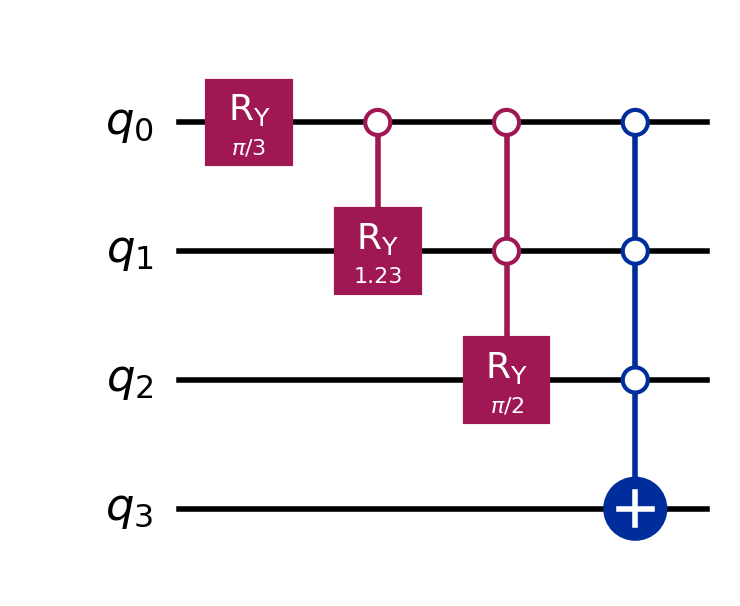

In [6]:
qc = w(4) #example of w state generator for n = 4
qc.draw("mpl")

In [7]:
state = Statevector.from_instruction(qc) # showcase of output of such state
state.draw("latex")

<IPython.core.display.Latex object>

In [8]:
def init_block(N:int, K:int) -> QuantumCircuit:
    """
    output:
        qc: initial setup of NK qubits
    input:
        N: number of nodes
        K: number of colors
    """
    qc = QuantumCircuit(N*K, name="Init")
    for i in range(N):
        qc.compose(w(K), range(i*K, (i+1)*K), inplace=True)
    return qc

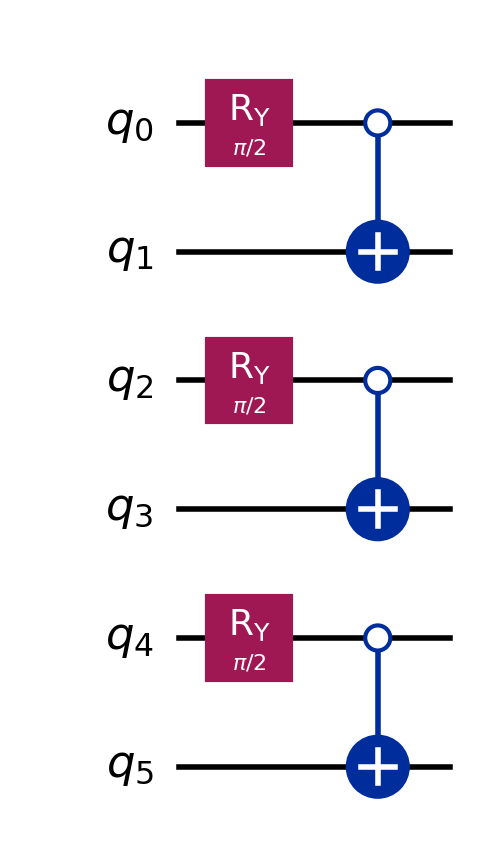

In [9]:
init_block(3,2).draw("mpl") # example of 3 nodes with 2 possible colors associated with them

### Marking

For each edge

$$
(v_i,v_j)\in E,
$$

an ancilla qubit is introduced to detect coloring conflicts. For every color (c), the corresponding qubits

$$
q_{i,c}
\quad\text{and}\quad
q_{j,c}
$$

are checked. If both are equal to 1, then the edge ancilla is activated, indicating that adjacent vertices share the same color.

Thus, an edge ancilla stores whether the corresponding edge violates the coloring constraint.

### Validation

After all edge conflicts have been evaluated, the edge ancillas are inverted so that

$$
a_e = 1
$$

indicates a valid edge and

$$
a_e = 0
$$

indicates a conflict.

A multi-controlled operation is then applied to all edge ancillas. The validation qubit is activated only if every edge satisfies the coloring constraint:

$$
V(x)=
\bigwedge_{e\in E}
a_e.
$$

Therefore,

$$
V(x)=1
$$

if and only if the coloring assignment ($x$) is valid.

In [10]:
def marking_block(N: int , K:int, edges:List[tuple]) -> QuantumCircuit:
    """
    output:
        qc: a QC to mark the edges of the graph on ancilla bits
    input:
        N: number of nodes
        K: number of colors
        edges: list of all the edges in the graph
    """
    NN = N*K + len(edges) + 1
    qc = QuantumCircuit(NN, name="Marking")
    for index, edge in enumerate(edges):
        for i in range(K):
            qc.ccx(edge[0]*K + i, edge[1]*K + i, N*K + index)
    controls = list(range(N*K, N*K + len(edges))) 
    qc.barrier()
    for i in range(len(edges)):
        qc.x(N*K + i)
    gate = XGate().control(num_ctrl_qubits=len(edges))
    qc.append(gate, controls + [NN-1])
    return qc

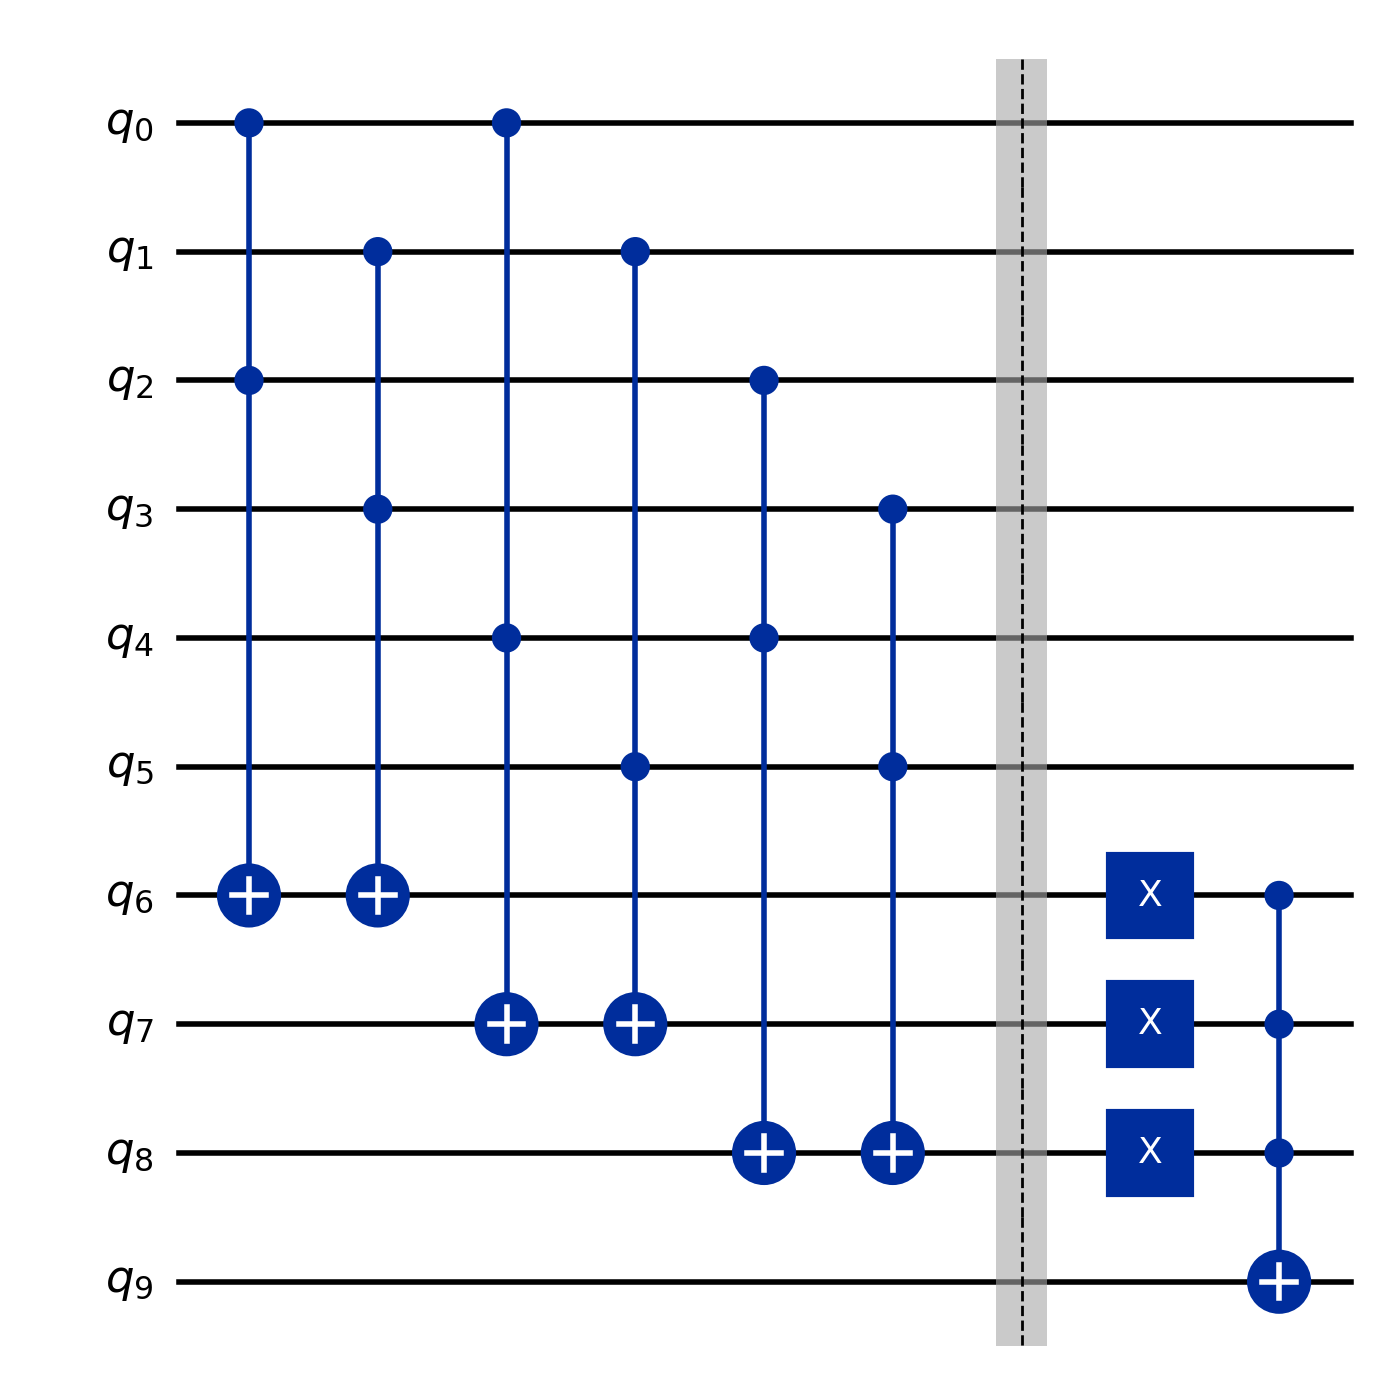

In [11]:
marking_block(3,2,[(0, 1), (0, 2), (1, 2)]).draw("mpl") # example

### Oracle

The oracle performs a phase flip on valid colorings:
$$
(-1)^{V(x)}
|x\rangle.
$$

Consequently,

$$
O|x\rangle = -|x\rangle
$$

for valid colorings, while invalid colorings remain unchanged.

After the phase flip, the marking and validation operations are reversed to restore all ancilla qubits to their initial states.

In [12]:
def oracle(N:int ,K: int , edges:List[tuple]) -> QuantumCircuit:
    """
    output:
        qc: Oracle consisting of NK qubits(encoding) + M qubits (number of edges present in the system) + 1 quabit (validity check) 
    input:
        N: number of nodes
        K: number of colors
        edges: list of all the edges in the graph
    """
    NN = N*K + len(edges) + 1
    mark = marking_block(N, K, edges)

    qc = QuantumCircuit(NN, name="Oracle")
    qc.compose(mark, inplace=True)            
    qc.z(NN-1)                                
    qc.compose(mark.inverse(), inplace=True)
    return qc

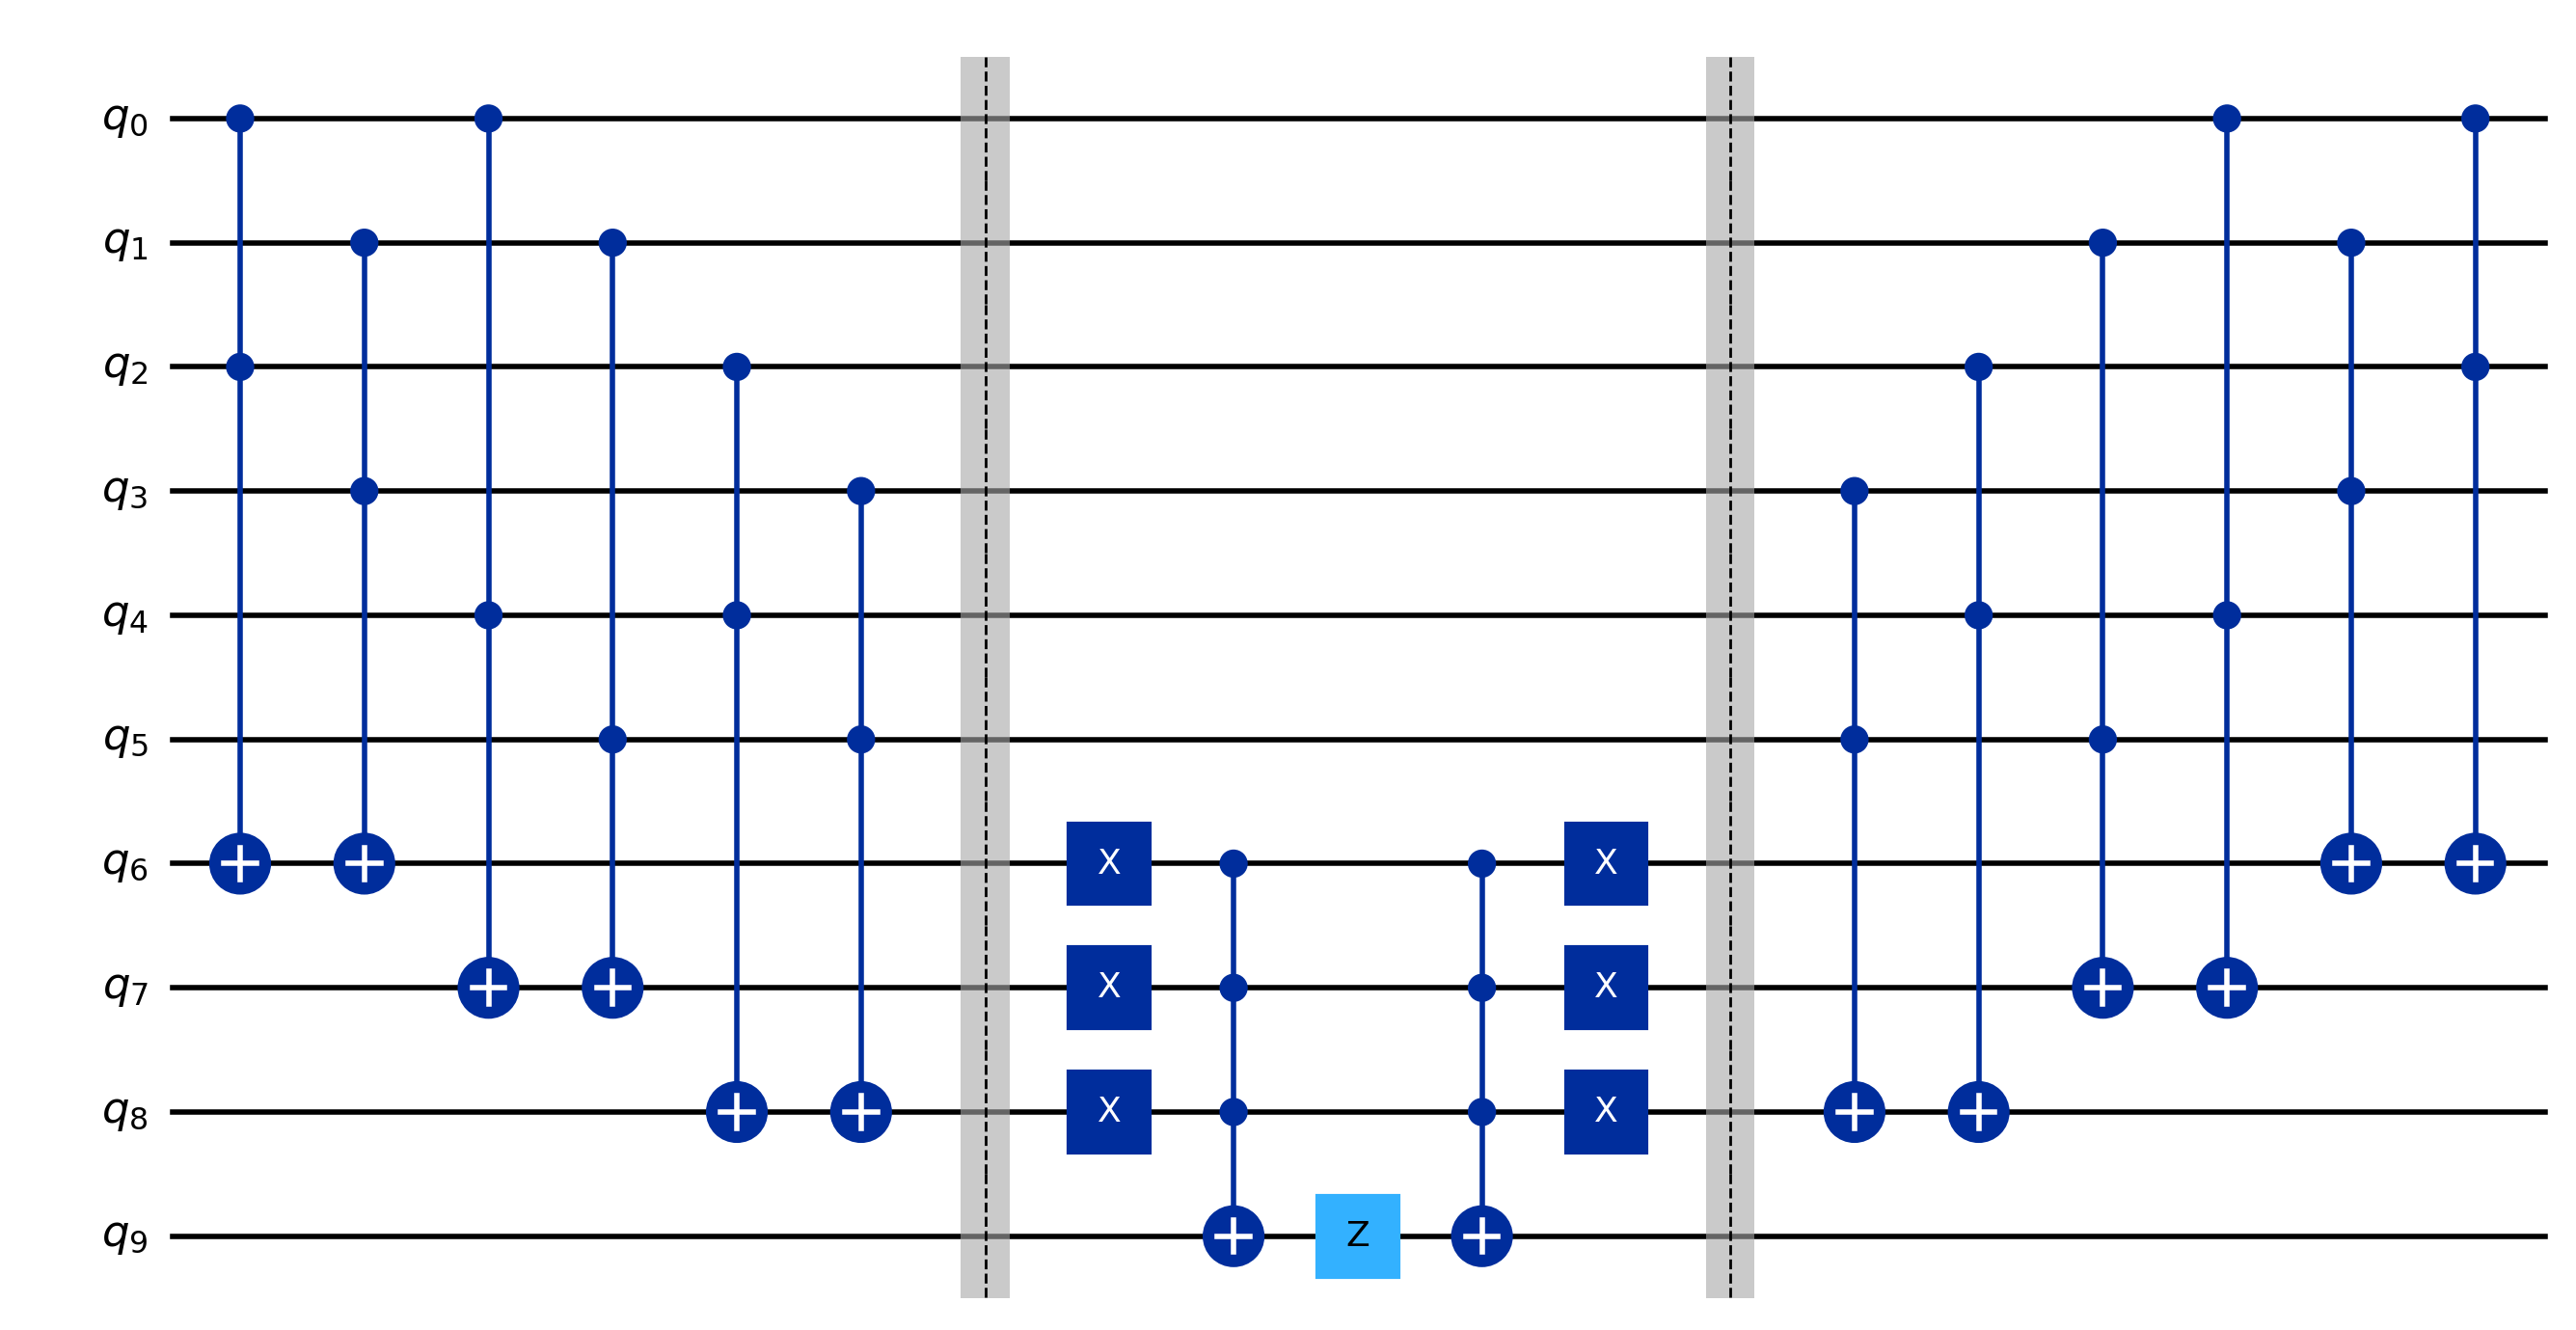

In [13]:
oracle(3,2,[(0, 1), (0, 2), (1, 2)]).draw("mpl") #example

### Diffusion Operator

Let

$$
|\psi_0\rangle
$$

be the initial superposition prepared by the initialization circuit. The diffusion operator performs a reflection about this state:

$$
2|\psi_0\rangle\langle\psi_0|
-I.
$$

In the implementation, the state is first mapped back to $(|0\rangle^{\otimes NK})$ using $(W_K^{-1})$, a phase reflection is applied to $(|0\rangle^{\otimes NK})$, and the state preparation operator is applied again.

In [14]:
def diffusion(N:int, K:int) -> QuantumCircuit:
    """
    output: 
        qc: diffusion function
    input:
        N: number of nodes
        K: number of colors
    """
    n = N*K
    init = init_block(N, K)

    qc = QuantumCircuit(n, name="Diffusion")
    qc.compose(init.inverse(), inplace=True)   # |psi> -> |0...0>

    qc.x(range(n))
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    qc.x(range(n))

    qc.compose(init, inplace=True)             # |0...0> -> |psi>
    return qc

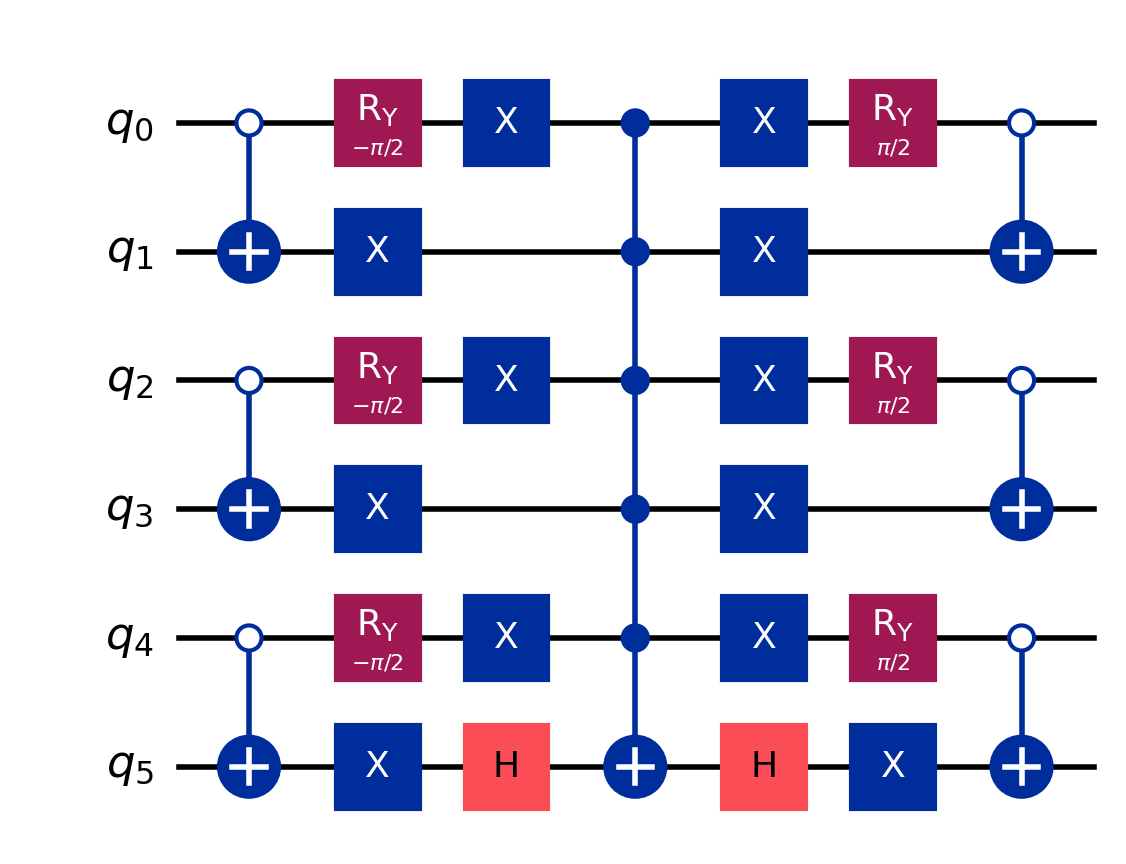

In [15]:
diffusion(3,2).draw("mpl") # example

### Grover Iteration

One Grover iteration consists of applying the oracle followed by the diffusion operator:

$$
G = D,O.
$$

Repeated applications of ($G$) increase the amplitudes of valid colorings while decreasing the amplitudes of invalid colorings.

After ($r$) iterations, the state becomes

$$
G^r|\psi_0\rangle.
$$

Finally, measurement is performed on the ($NK$) encoding qubits, producing a coloring assignment with high probability.

In [16]:
def grover_step(N:int ,K: int , edges:List[tuple]) -> QuantumCircuit: # helper function to make repetition easier
    """
    output:
        qc: Oracle + Diffusion
    input:
        N: number of nodes
        K: number of colors
    """
    NN = N*K + len(edges) + 1
    n = N*K

    qc = QuantumCircuit(NN, name="Grover Step")
    qc.compose(oracle(N, K, edges), inplace=True)
    qc.compose(diffusion(N, K), qubits=range(n), inplace=True)
    return qc

In [17]:
def full_circuit(N:int ,K: int , edges:List[tuple], iterations:int):
    
    NN = N*K + len(edges) + 1
    n = N*K

    qc = QuantumCircuit(NN, n)
    qc.compose(init_block(N, K), qubits=range(n), inplace=True)

    step = grover_step(N, K, edges)
    for _ in range(iterations):
        qc.compose(step, inplace=True)

    qc.measure(range(n), range(n))
    return qc

In [18]:
def full_circuit_without_measurement(N, K, edges, iterations):
    NN = N*K + len(edges) + 1
    n = N*K

    qc = QuantumCircuit(NN, n)
    qc.compose(init_block(N, K), qubits=range(n), inplace=True)

    step = grover_step(N, K, edges)
    for _ in range(iterations):
        qc.compose(step, inplace=True)

    return qc

In [19]:
def run_simulation(qc):
    backend = Aer.get_backend("qasm_simulator")
    transpiled = transpile(qc,backend)
    job = backend.run(transpiled , shots = 1024)
    result = job.result()
    counts = result.get_counts()
    return counts

### Estimation of Grover Iterations

The number of Grover iterations used in the algorithm is estimated using the standard optimal search expression:

$$
r \approx \frac{\pi}{4}\sqrt{\frac{D}{M}},
$$

where ($D$) is the size of the search space and ($M$) is the number of valid solutions.

In the k-coloring encoding, each of the ($N$) nodes can take one of ($K$) colors, so the total search space is

$$
D = K^N.
$$

The number of valid colorings depends on the structure of the graph. In this implementation, it is assumed to be on the order of

$$
M \sim N!.
$$

Substituting these values gives the estimate

$$
r \approx \frac{\pi}{4}\sqrt{\frac{K^N}{N!}}.
$$

This expression is used as a heuristic to choose the number of Grover iterations before measurement.

In [20]:
def get_iteration(N , K):
    itera = np.pi/4 * np.sqrt(K**N/factor(N))
    return max(1, int(itera))

\newpage
## Examples
### 1. Linear Graph

The first example considers a linear graph with $(N=3)$ nodes and $(K=2)$ colors. The graph contains the edges

$$
(0,1),\ (1,2).
$$

For this instance, a single Grover iteration was applied. Since the search space is relatively small and the graph admits multiple valid colorings, the amplification process quickly increases the probability of measuring a valid solution. The measurement results show a concentration of probability on states corresponding to valid 3-colorings of the graph.

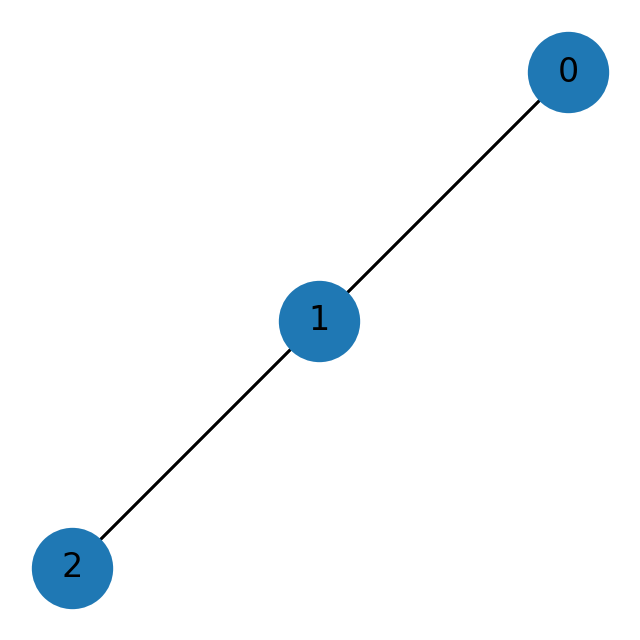

In [21]:
# Initial Setup
N = 3
graph = {
    0:{1},
    1:{0,2},
    2:{1}
}
G = get_graph(graph)
edges = get_edges(graph)
pos = get_pos(G)
draw_simple_graph(G, pos)

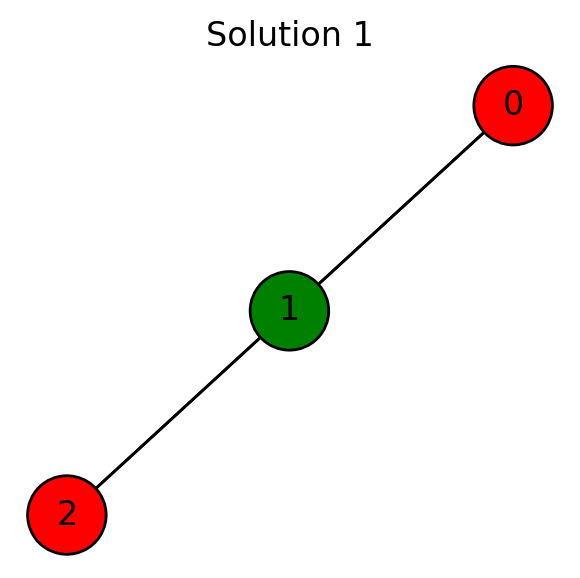

In [22]:
# Classical Solution
coloring, color = greedy(N,graph)
K = len(color) # estimating color needed from classical solution
iterations = get_iteration(N,K)
draw_graph([coloring] ,G, pos)

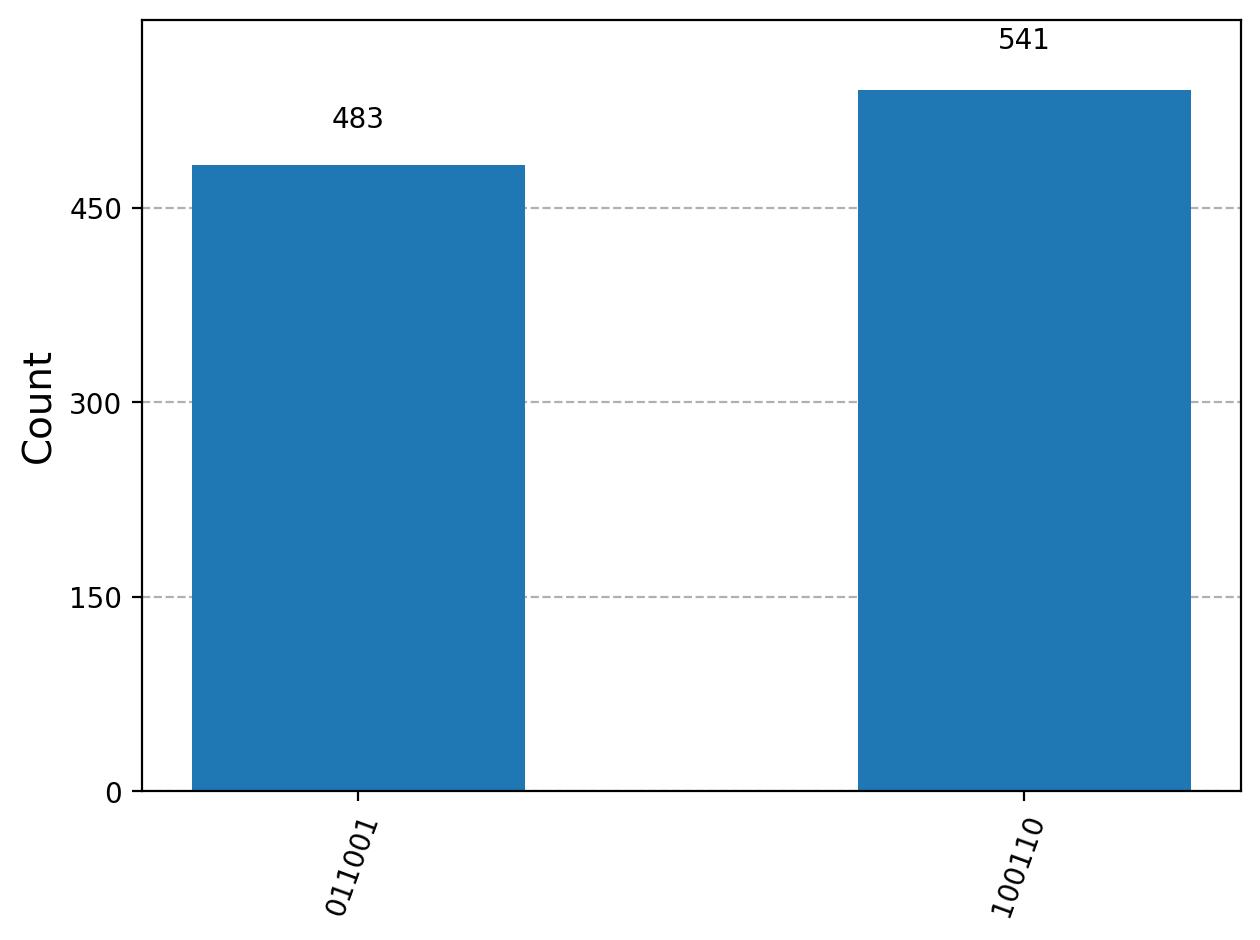

In [23]:
qc = full_circuit(N,K,edges , iterations=iterations)
counts = run_simulation(qc)
plot_histogram(counts)

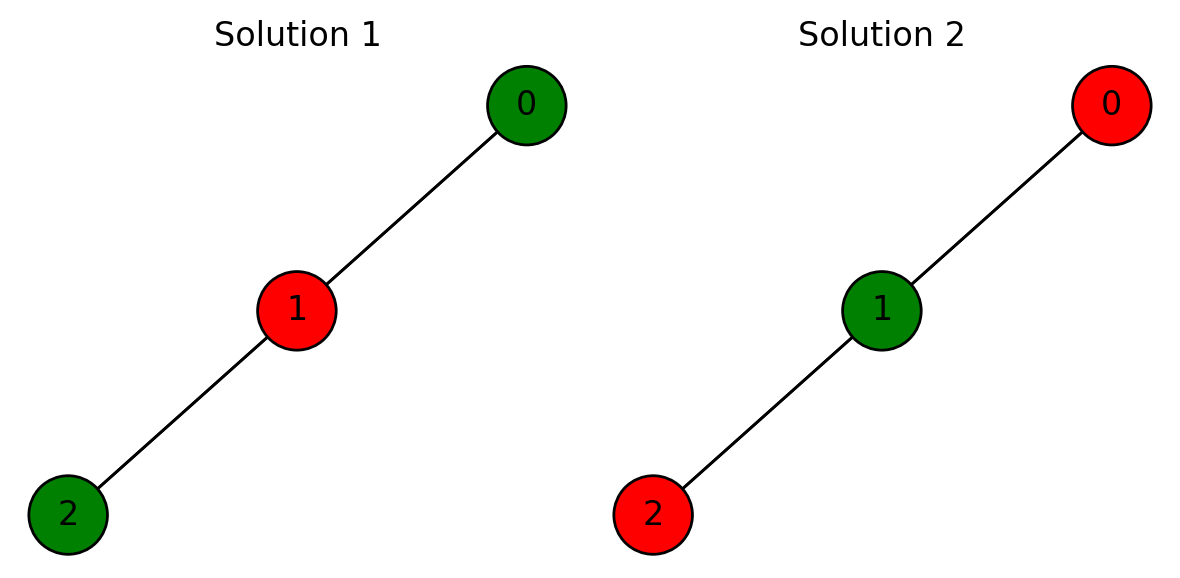

In [24]:
colorings = translator(N,K,counts)
colorings = answer_validity(colorings, edges)
draw_graph(colorings , G, pos)

### 2. Cyclic Graph

The second example considers a cyclic graph with (N=3) nodes and (K=3) colors. The graph contains the edges

$$
(0,1),\ (1,2),\ (2,0).
$$

This graph forms a triangle, requiring all three vertices to receive different colors. For this instance, nine Grover iterations were applied. The repeated oracle and diffusion operations amplify the amplitudes of valid colorings, increasing the probability of measuring a state that satisfies all coloring constraints. The final measurement distribution is therefore expected to be dominated by valid 3-colorings of the cycle.

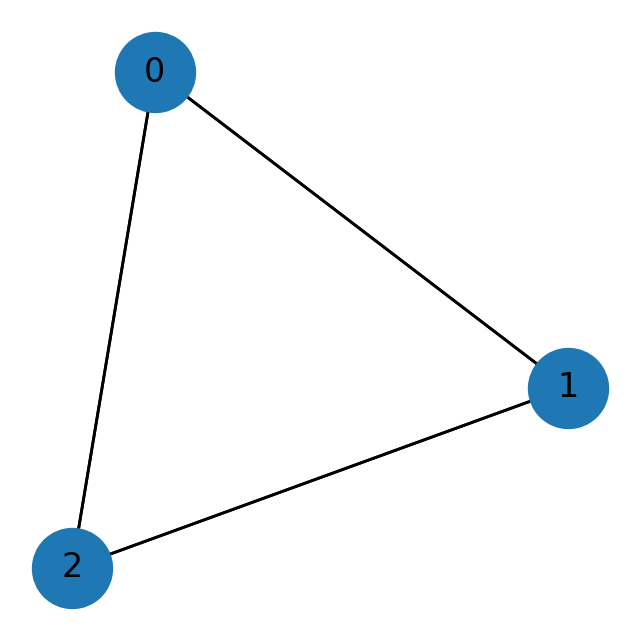

In [25]:
# Initial Setup
N = 3
graph = {
    0:{1,2},
    1:{0,2},
    2:{1,0}
}
G = get_graph(graph)
edges = get_edges(graph)
pos = get_pos(G)
draw_simple_graph(G, pos)

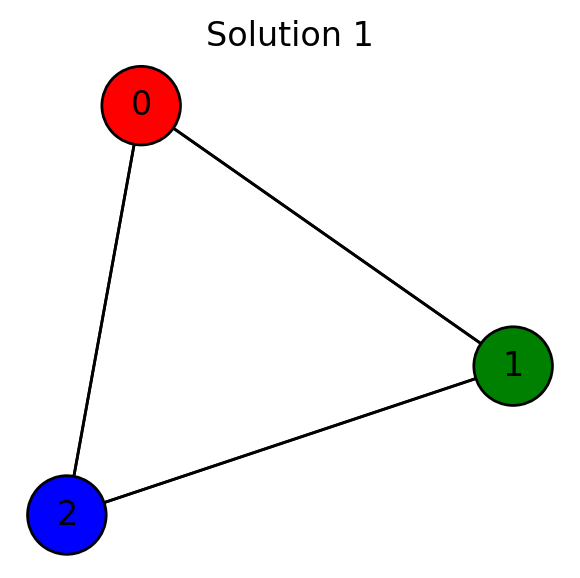

In [26]:
# Classical Solution
coloring, color = greedy(N,graph)
K = len(color)
iterations = get_iteration(N,K)
draw_graph([coloring] ,G, pos)

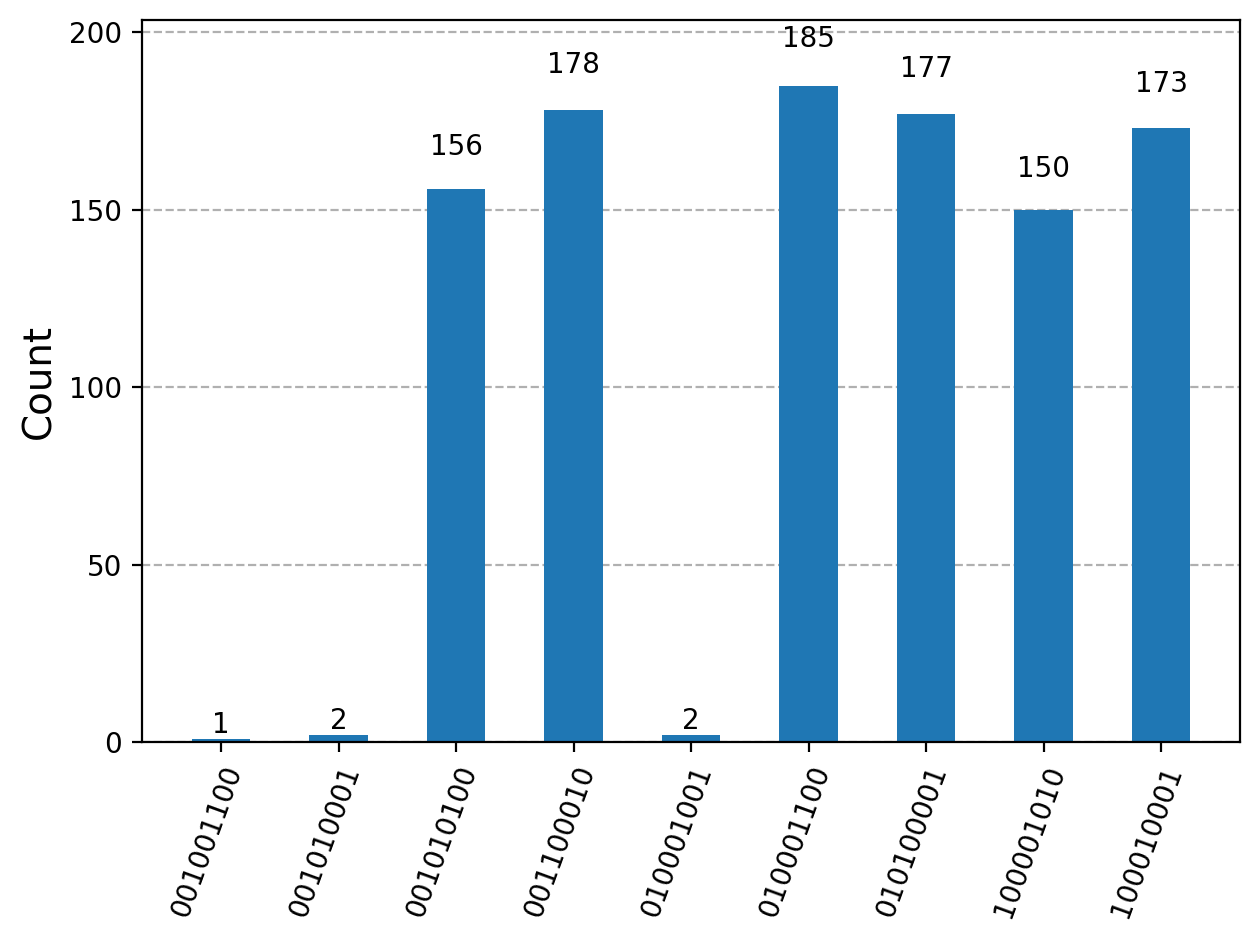

In [27]:
qc = full_circuit(N,K,edges , iterations=iterations)
counts = run_simulation(qc)
plot_histogram(counts)

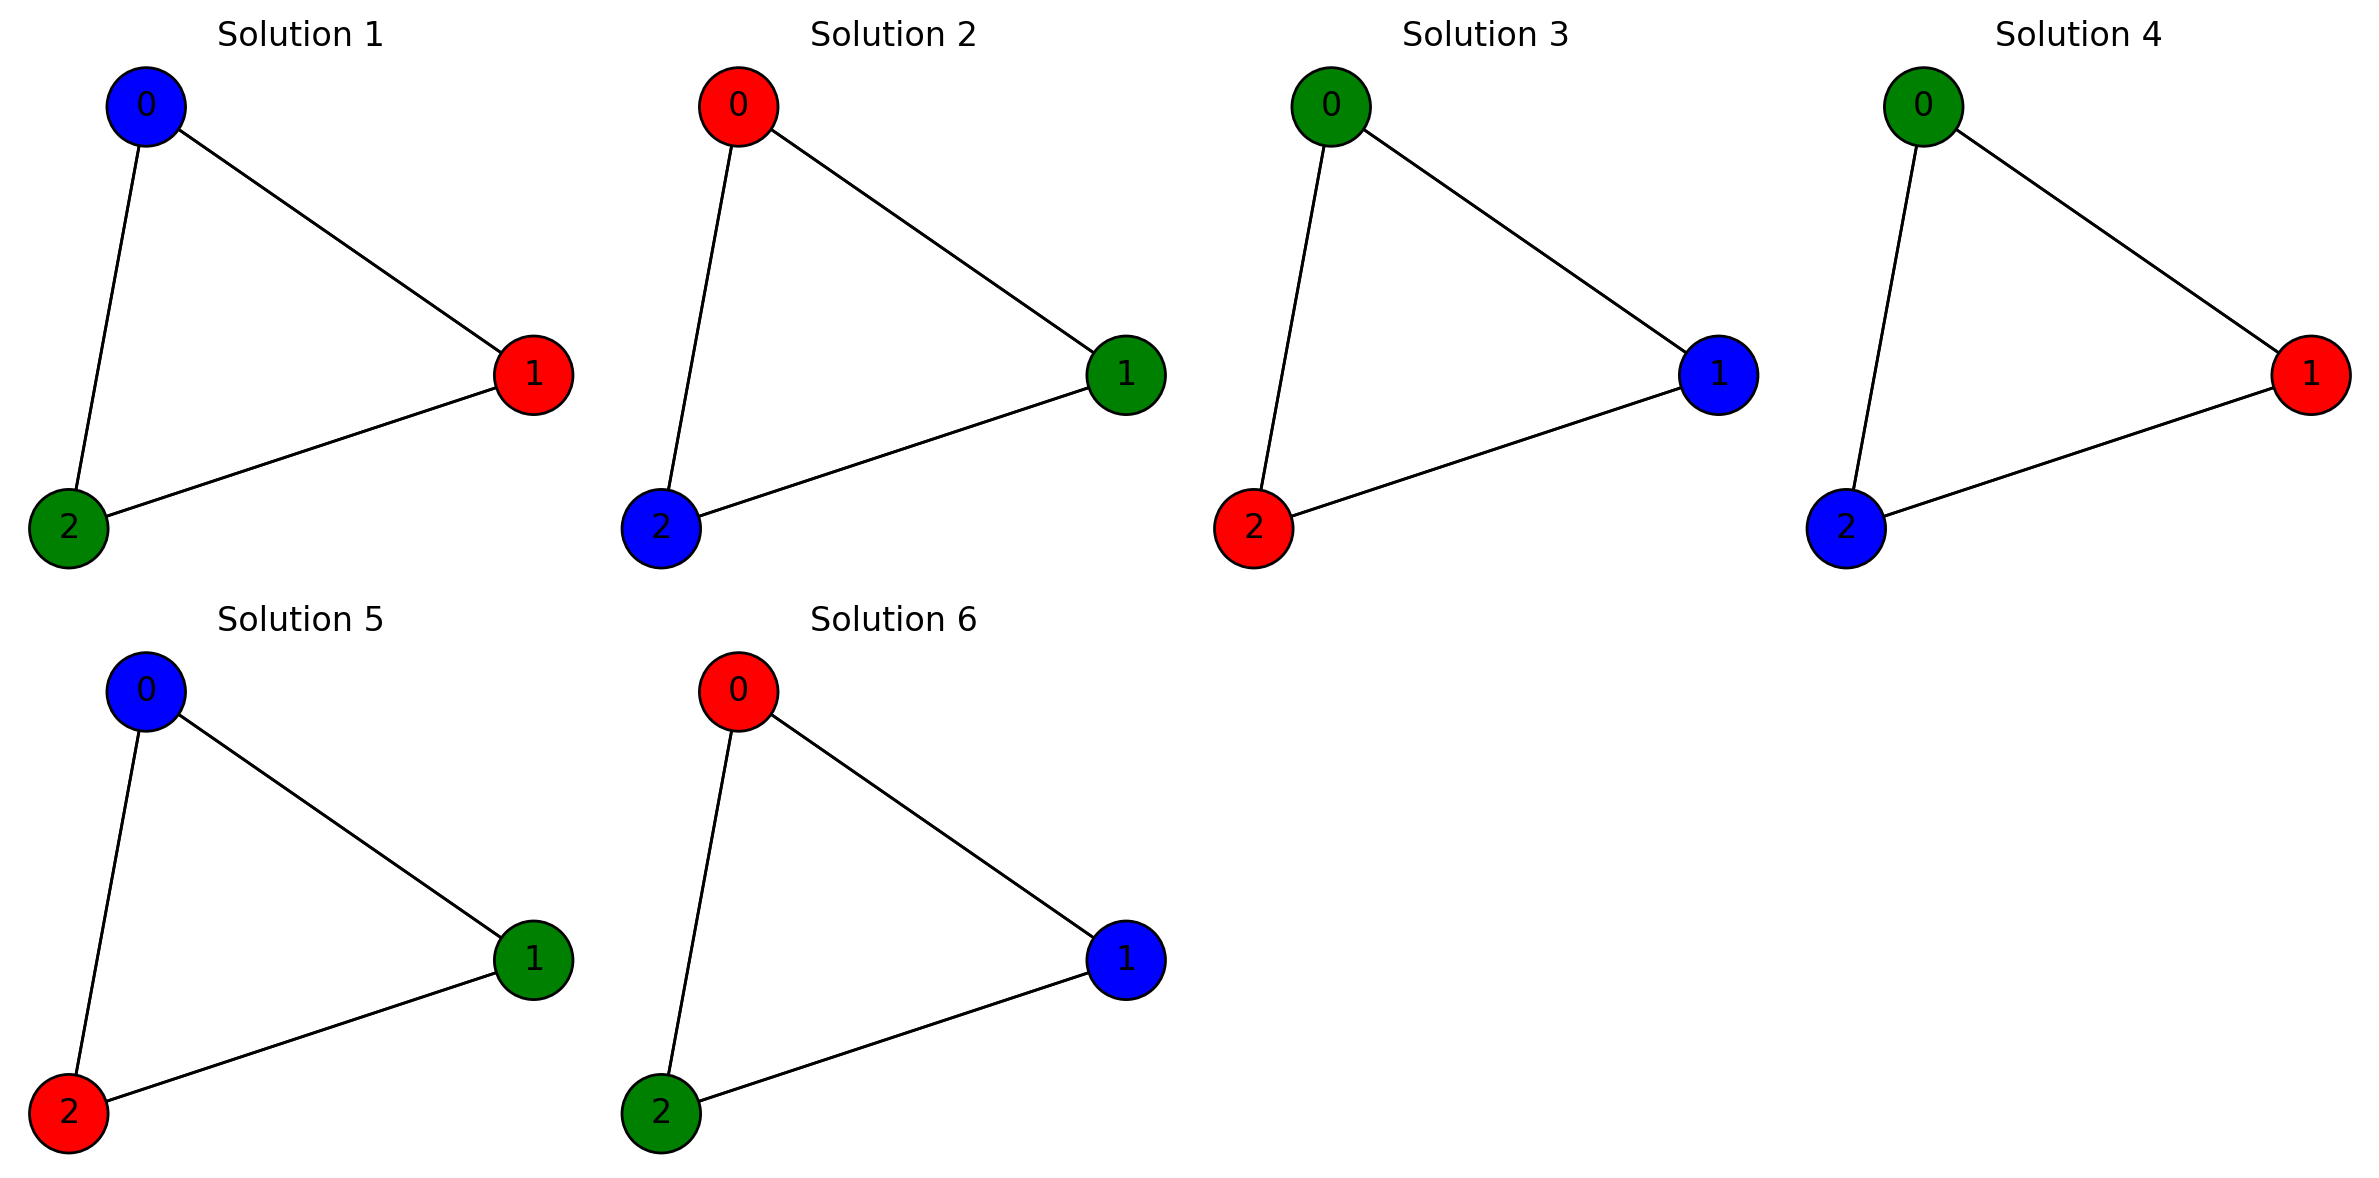

In [28]:
colorings = translator(N,K,counts)
colorings = answer_validity(colorings, edges)
draw_graph(colorings , G, pos)

### 3. 4-Node Graph

The following graph was used as an additional test case:

$$
(0, 1),\ (0, 2),\ (1, 2),\ (0, 3)
$$

This graph consists of a triangle formed by nodes $(0,1,2)$, with an additional node $(3)$ connected only to node $(0)$.

For $(K=3)$, nodes $(0,1,2)$ require all three colors to satisfy the triangle constraint, while node $(3)$ must take a color different from node $(0)$. This structure increases the number of valid colorings compared to a complete graph, while still maintaining non-trivial constraints.

The example was used to test the behavior of the quantum circuit on a slightly more complex topology than simple linear or cyclic graphs, and to observe how the algorithm scales with additional connectivity.

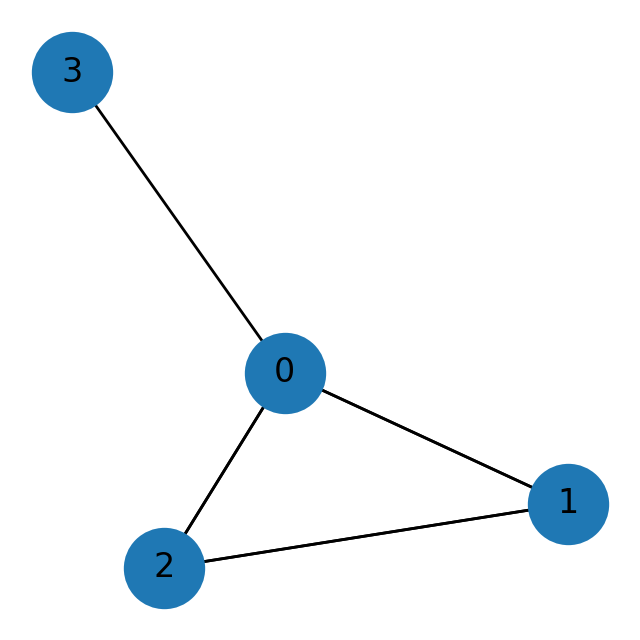

In [29]:
# Initial Setup
N = 4
graph = {
    0: {1,2},
    1: {0,2},
    2: {0,1},
    3:{0}
}
G = get_graph(graph)
edges = get_edges(graph)
pos = get_pos(G)
draw_simple_graph(G, pos)

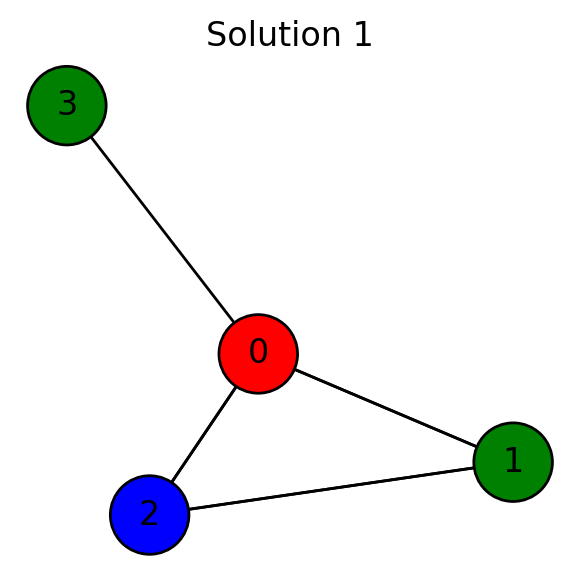

In [30]:
# Classical Solution
coloring, color = greedy(N,graph)
K = len(color) 
iterations = get_iteration(N,K)
draw_graph([coloring] ,G, pos)

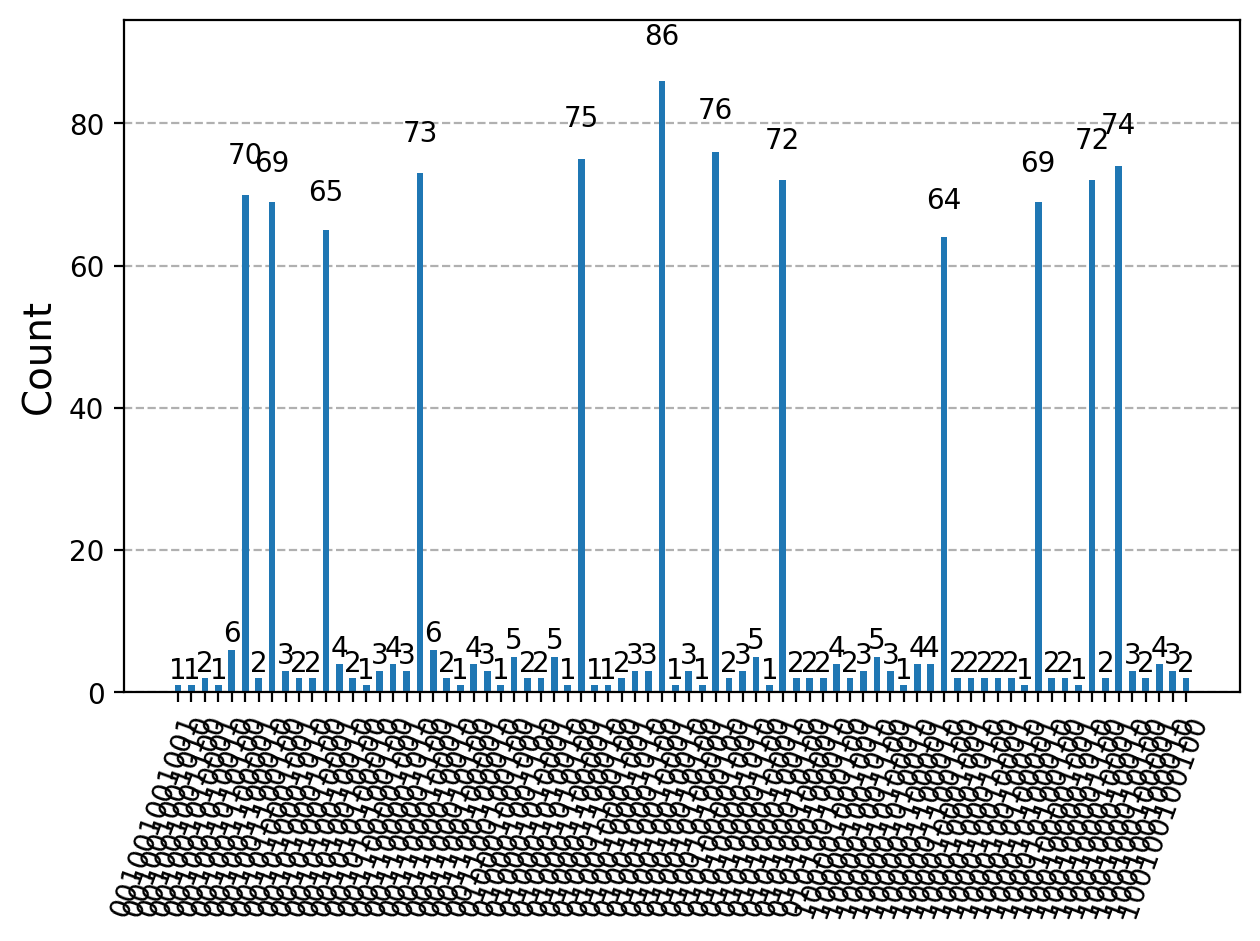

In [31]:
qc = full_circuit(N,K,edges , iterations=iterations)
counts = run_simulation(qc)
plot_histogram(counts) # graph is not readable uncomment on your own risk

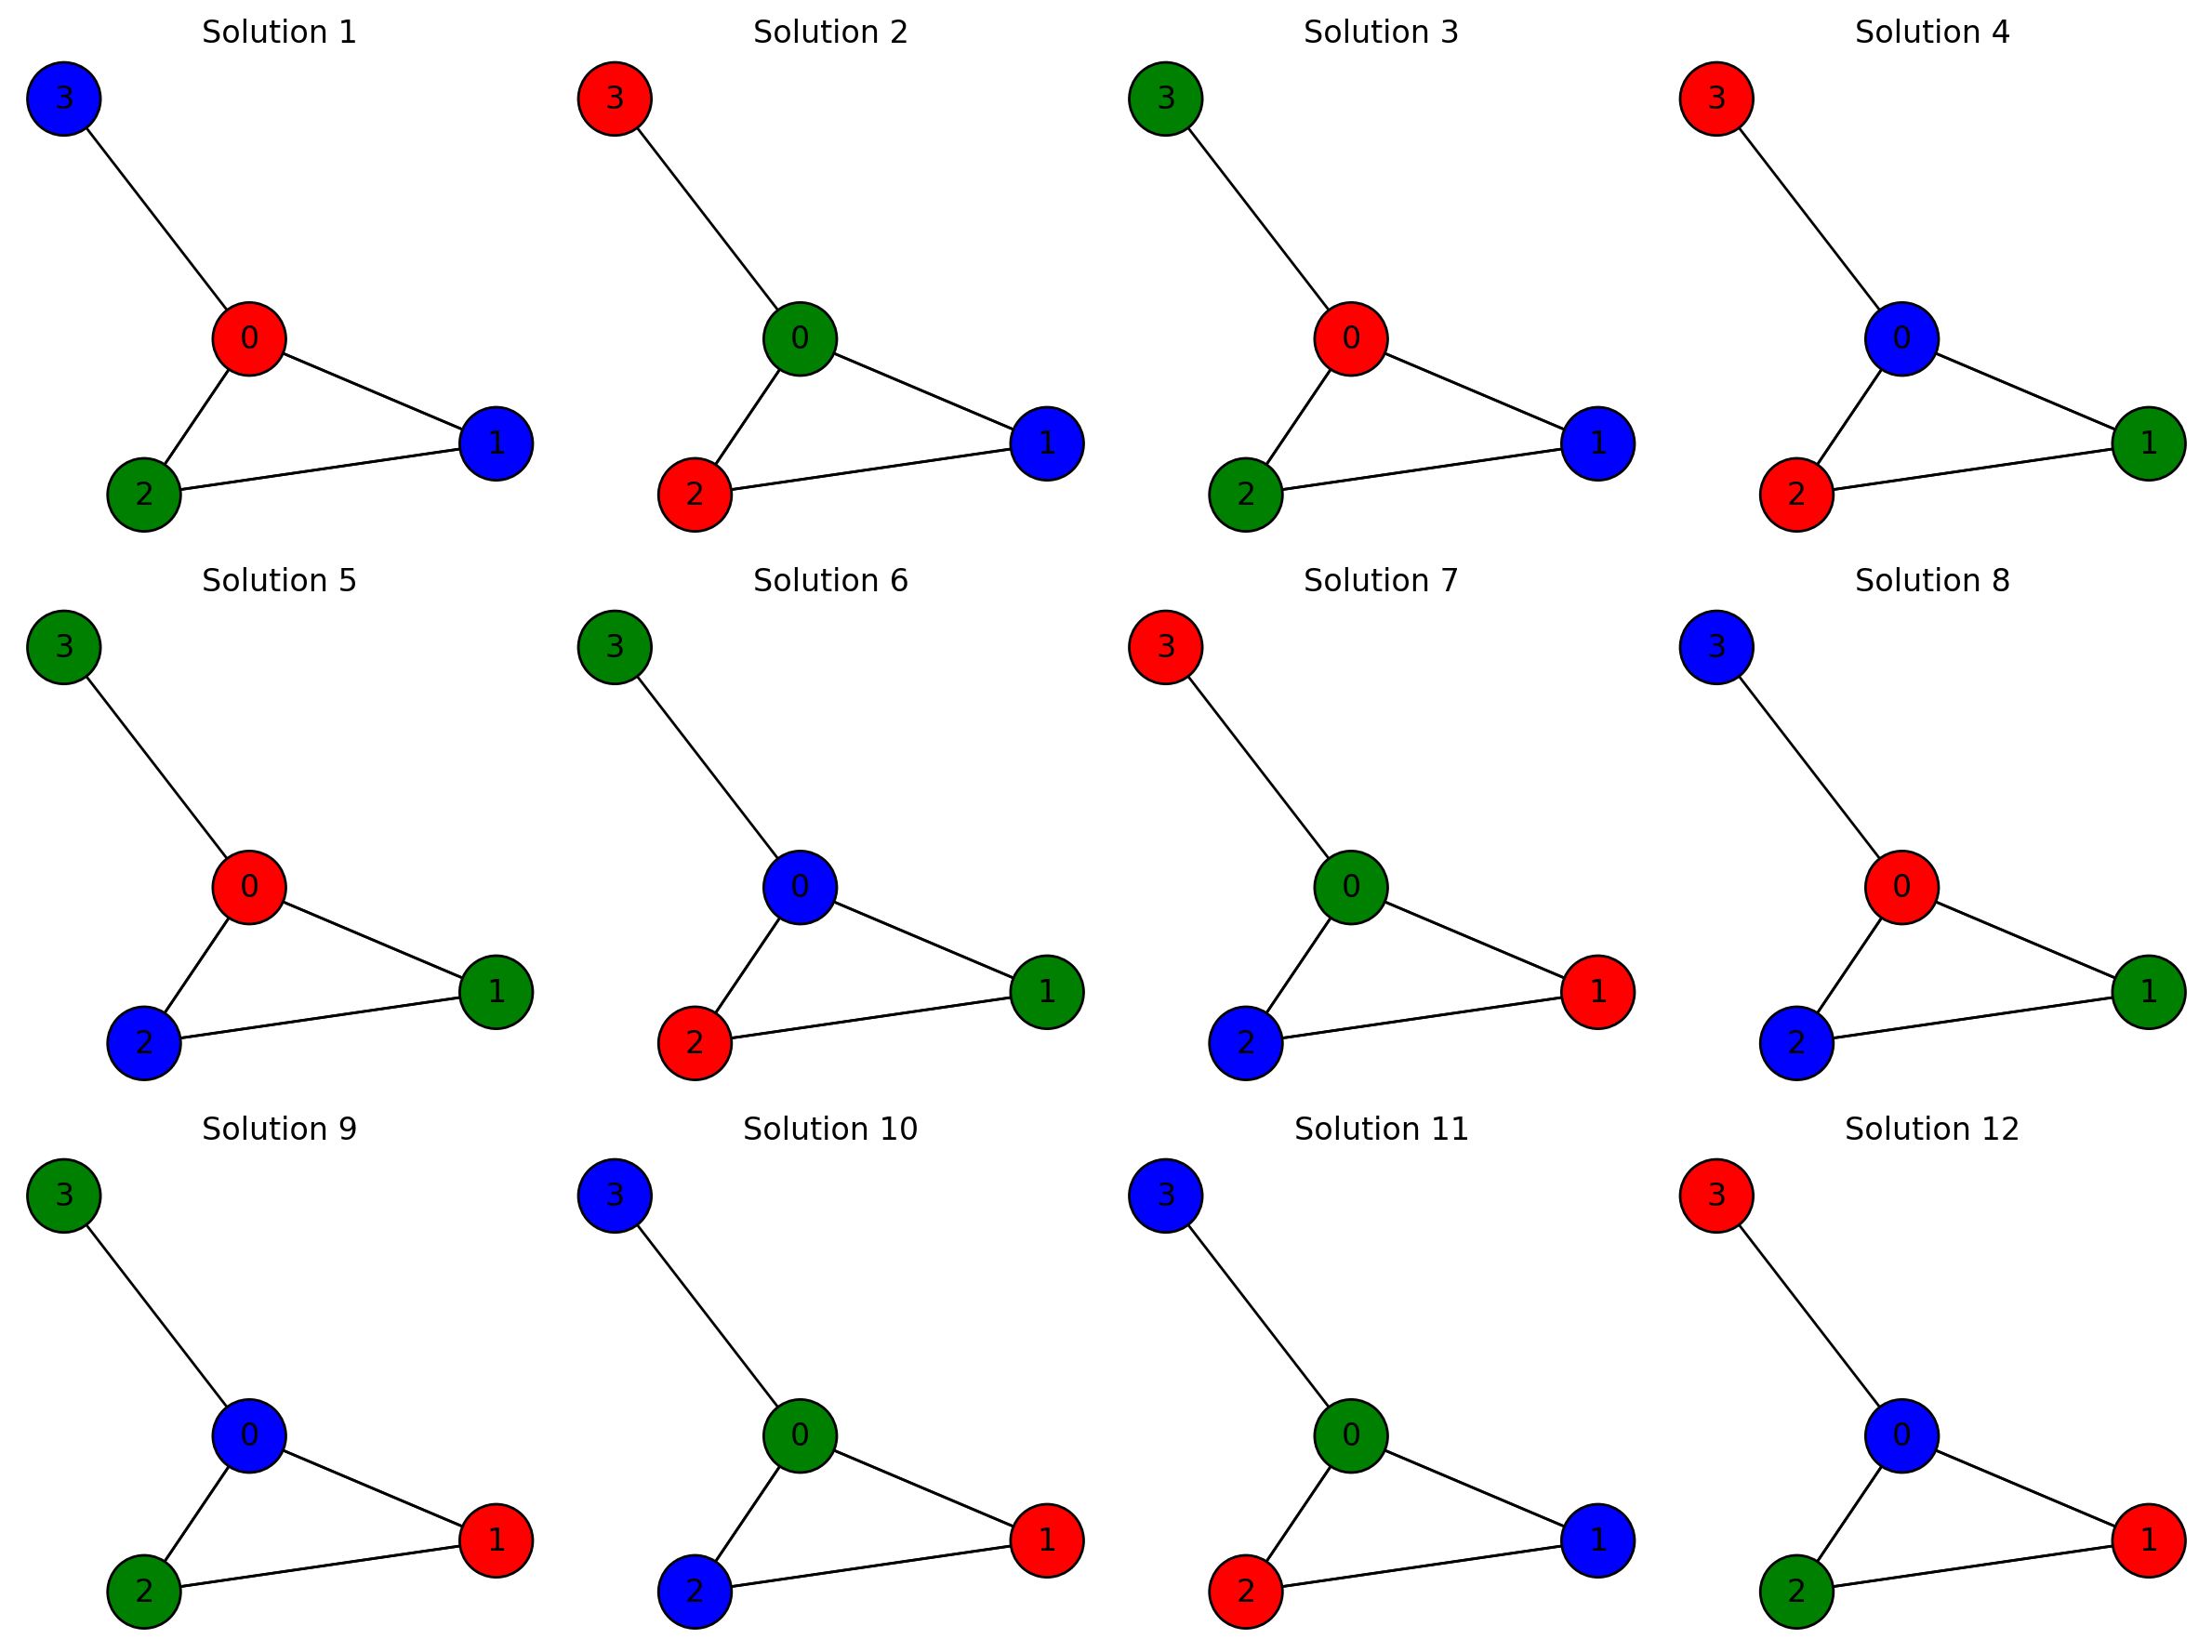

In [32]:
colorings = translator(N,K,counts)
colorings = answer_validity(colorings, edges)
draw_graph(colorings , G, pos)

### 4. 5-Node Graph

The following graph was used as an additional test case:

$$
(0, 1),\ (2, 4),\ (1, 2),\ (0, 4),\ (0, 3),\ (0, 2),\ (1, 3)
$$

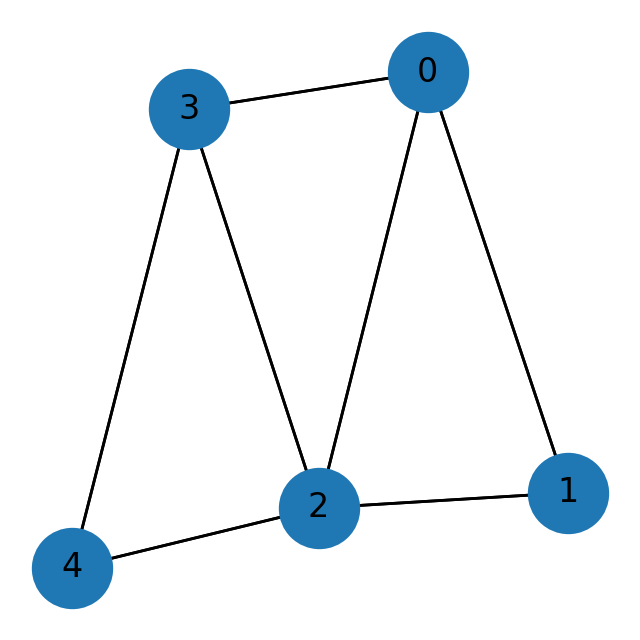

In [33]:
# Initial Setup
N = 5
graph = {
    0: {1,2,3},
    1: {0,2},
    2: {0,1,3,4},
    3: {0,2,4},
    4: {3,2}
   
}
G = get_graph(graph)
edges = get_edges(graph)
pos = get_pos(G)
draw_simple_graph(G, pos)

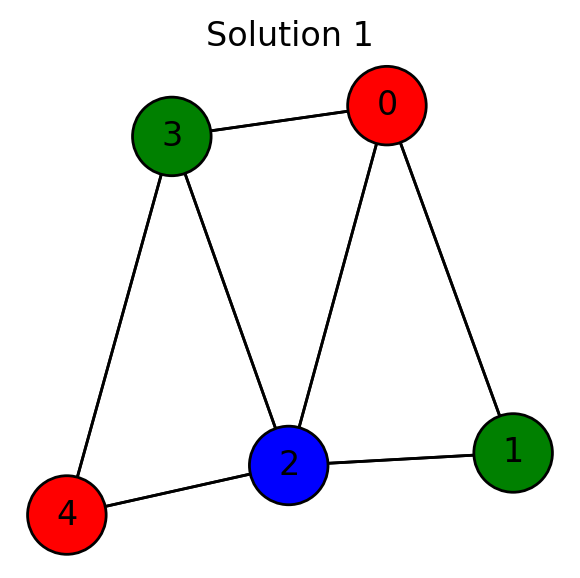

In [34]:
# Classical Solution
coloring, color = greedy(N,graph)
K = len(color) 
iterations = get_iteration(N,K) +3 # works better with + 3 for graph
draw_graph([coloring] ,G, pos)

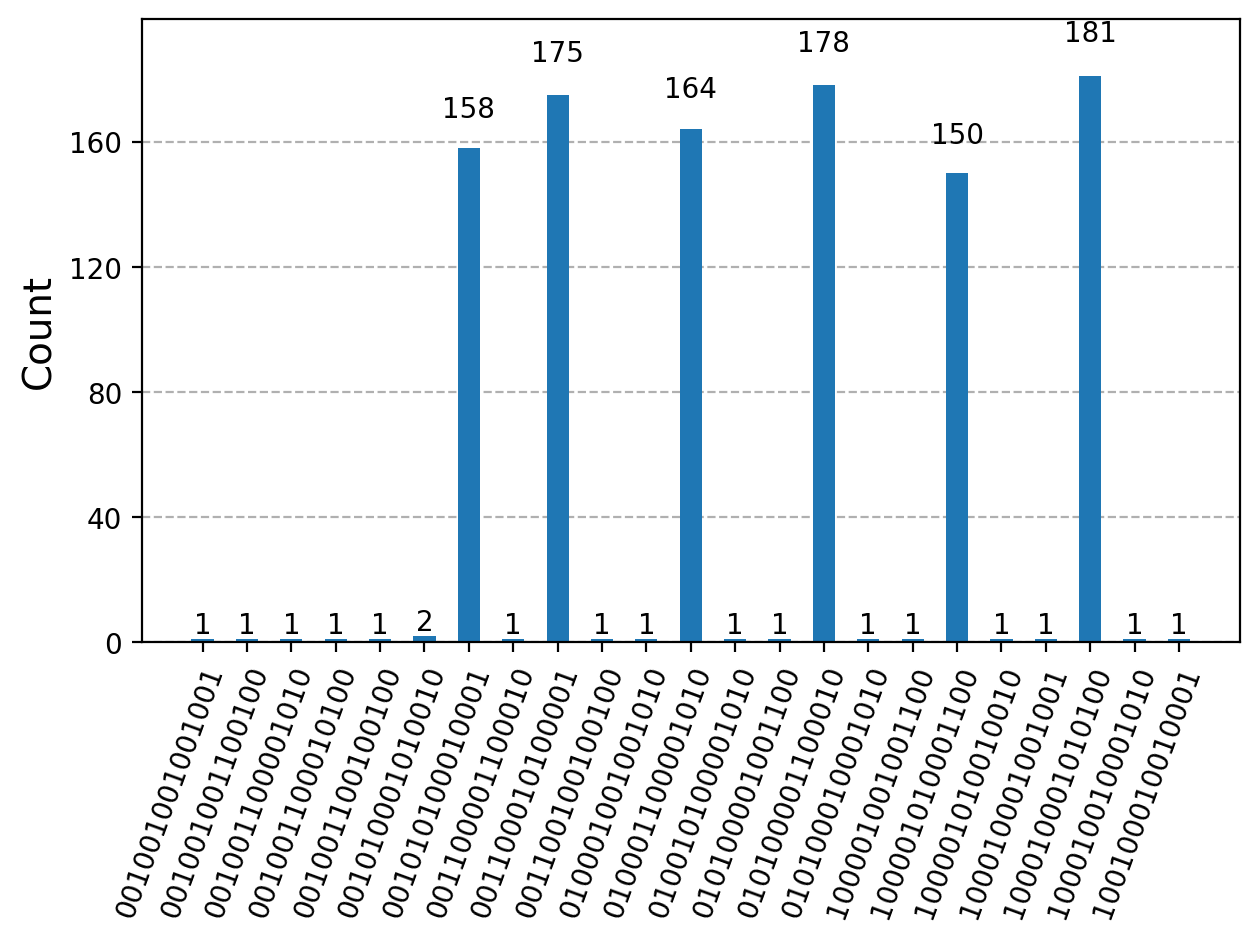

In [35]:
qc = full_circuit(N,K,edges , iterations=iterations)
counts = run_simulation(qc)
plot_histogram(counts) # graph is not readable uncomment on your own risk

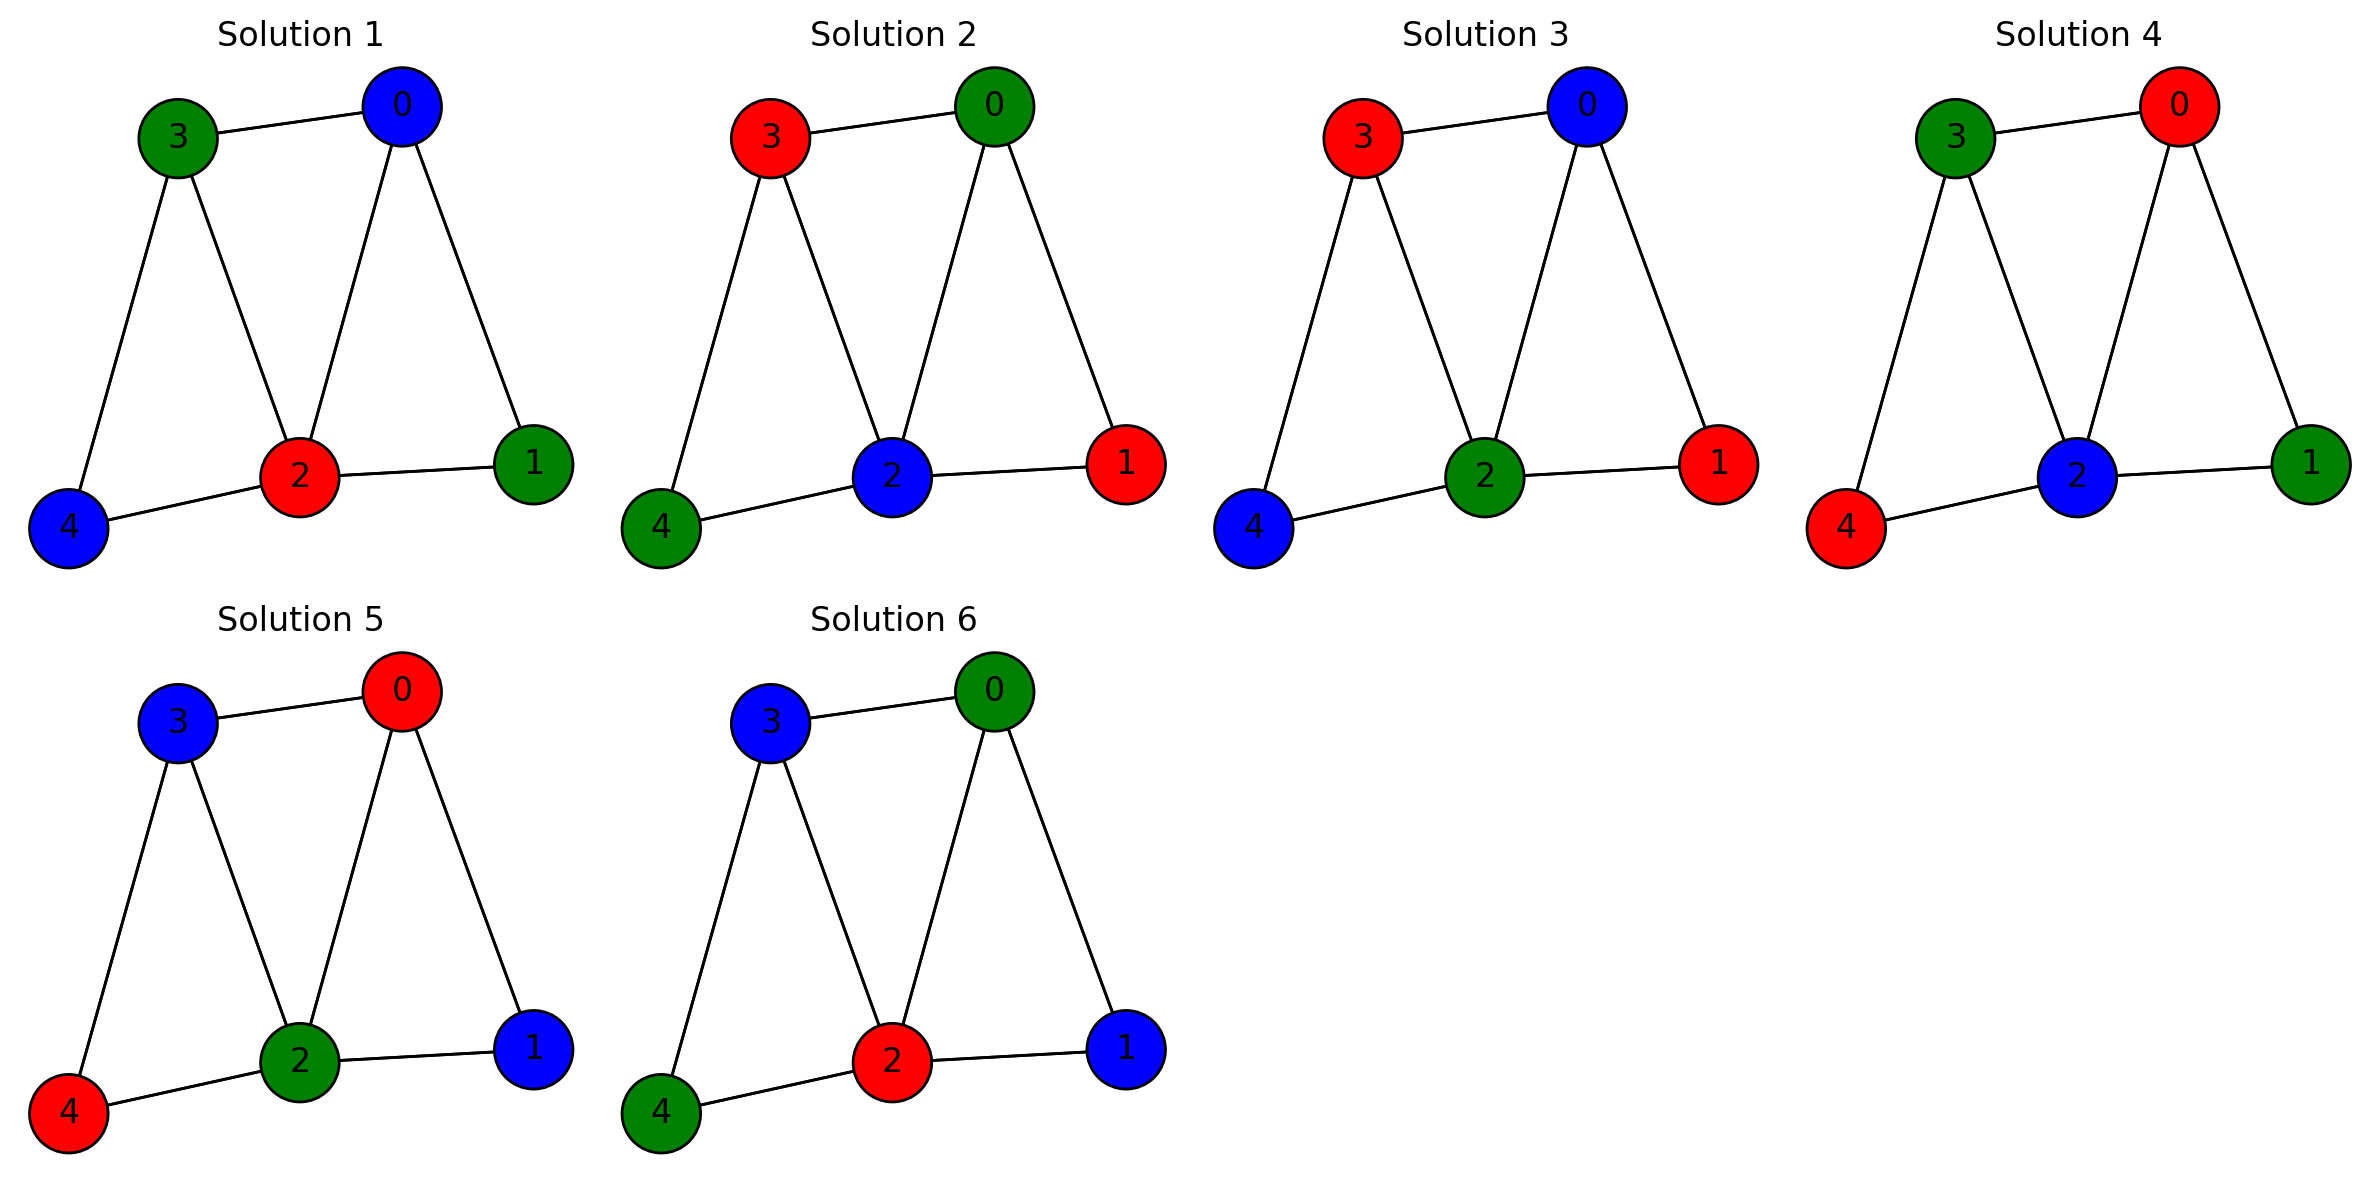

In [36]:
colorings = translator(N,K,counts)
colorings = answer_validity(colorings, edges)
draw_graph(colorings , G, pos)

### 5. 5-Node Star Graph

The following graph was used as an additional test case:
$$
(2, 3),\ (0, 2),\ (1, 2),\ (2, 4)
$$

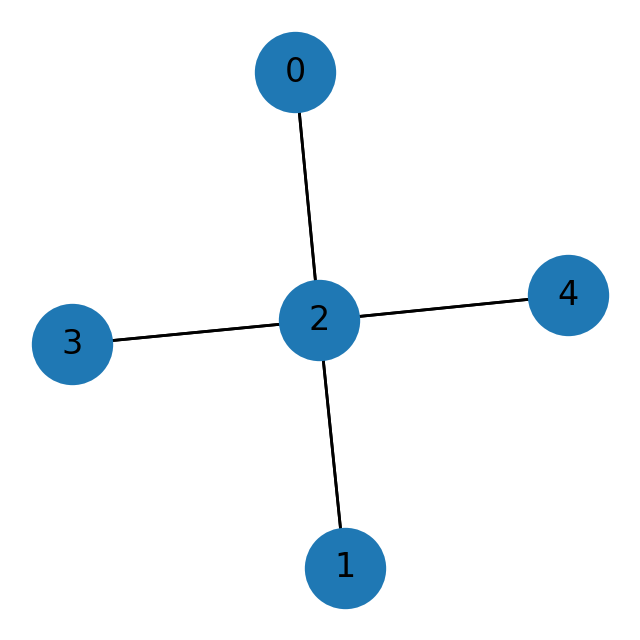

In [37]:
N = 5
graph = {
    0: {2},
    1: {2},
    2: {0,1,3,4},
    3: {2},
    4: {2}
   
}
G = get_graph(graph)
edges = get_edges(graph)
pos = get_pos(G)
draw_simple_graph(G, pos)

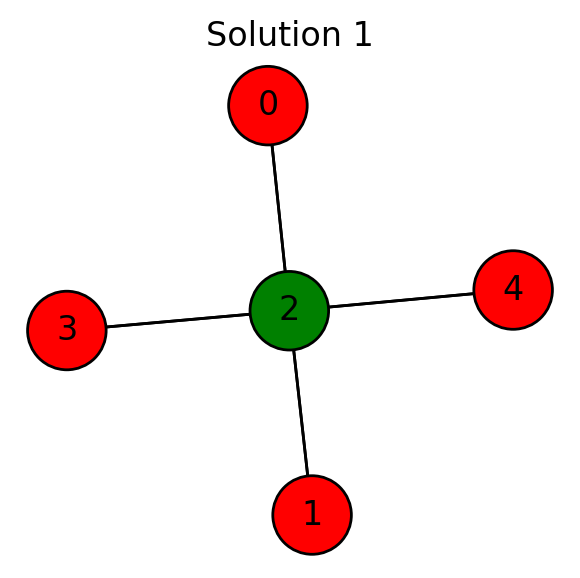

In [38]:
# Classical Solution
coloring, color = greedy(N,graph)
K = len(color) 
iterations = get_iteration(N,K)+1 # it worked better with that +1 
draw_graph([coloring] ,G, pos)

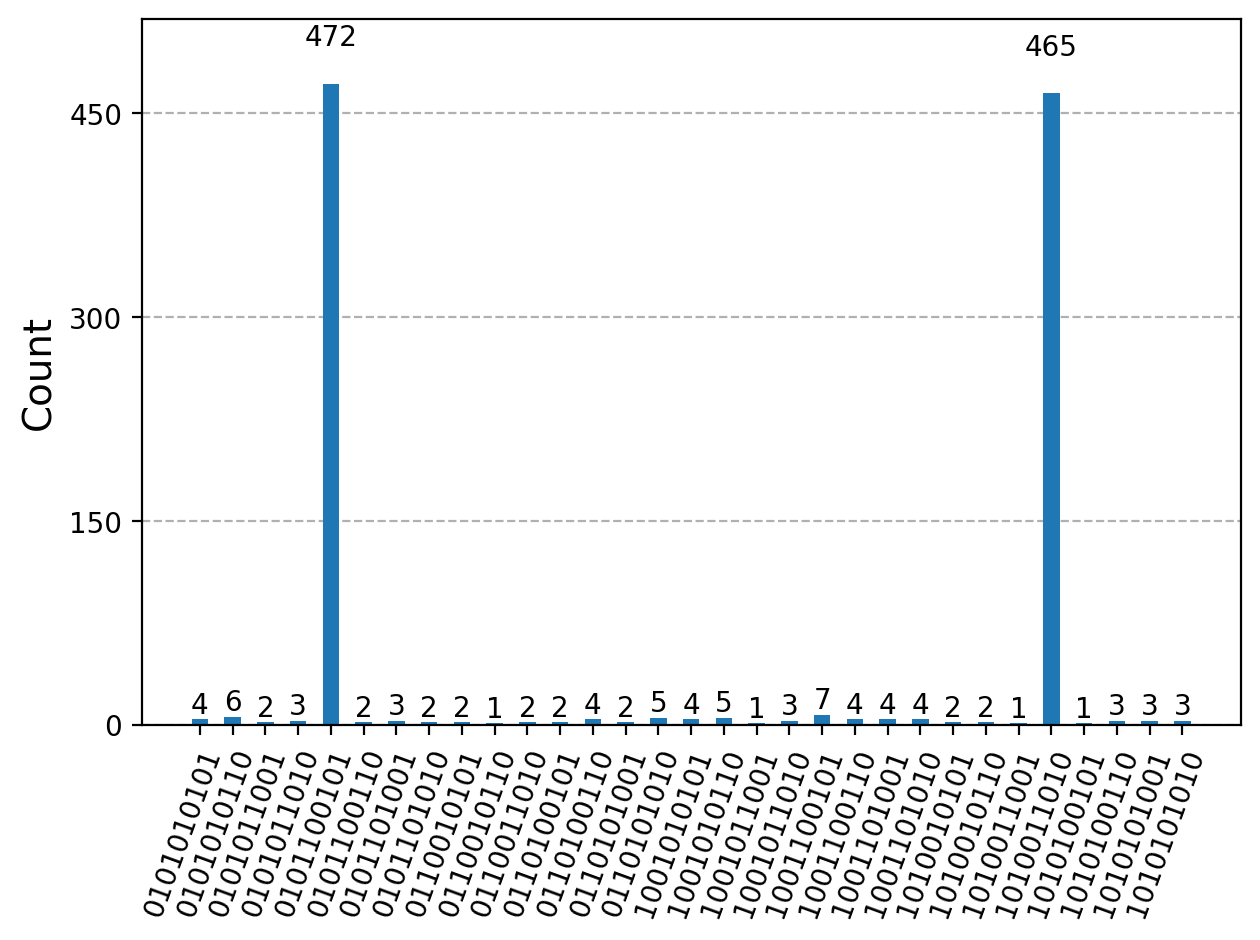

In [39]:
qc = full_circuit(N,K,edges , iterations=iterations)
counts = run_simulation(qc)
plot_histogram(counts) # graph is not readable uncomment on your own risk

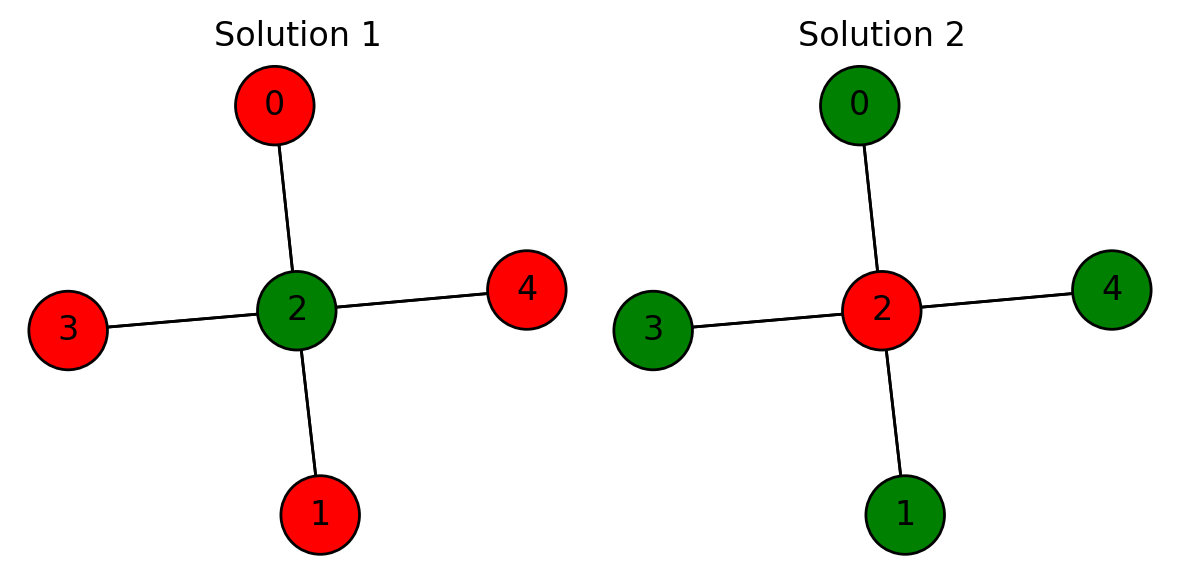

In [40]:
colorings = translator(N,K,counts)
colorings = answer_validity(colorings, edges)
draw_graph(colorings , G, pos)

### 6. 6-Node Graph

The following graph was used as an additional test case:
$$
(1, 2), (0, 4), (3, 4), (1, 4), (2, 3), (0, 2), (2, 5), (3, 5)
$$

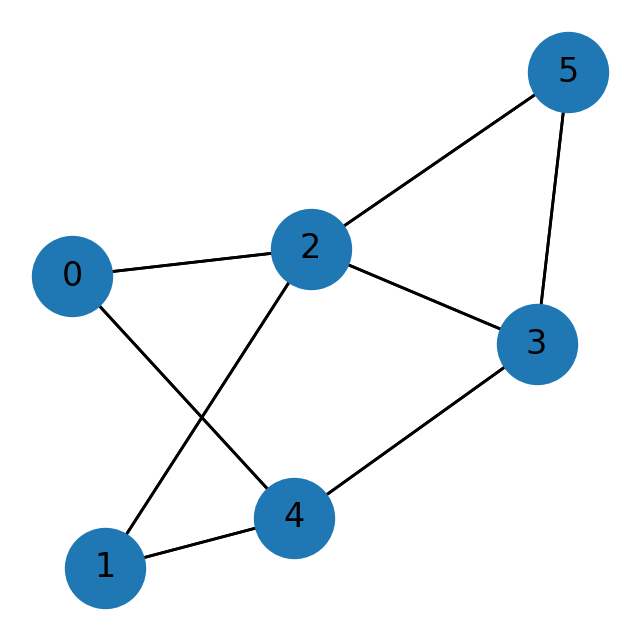

In [45]:
N = 6
graph = {0: {2, 4},
         1: {2, 4},
         2: {0, 1, 3, 5}, 
         3: {2, 4, 5}, 
         4: {0, 1, 3}, 
         5: {2, 3}}
G = get_graph(graph)
edges = get_edges(graph)
pos = get_pos(G)
draw_simple_graph(G, pos)

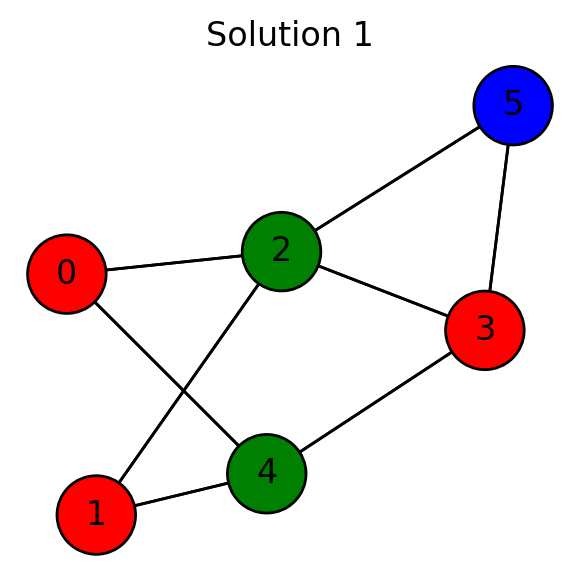

In [46]:
# Classical Solution
coloring, color = greedy(N,graph)
K = len(color) 
iterations = get_iteration(N,K)+1 # it worked better with that +1 
draw_graph([coloring] ,G, pos)

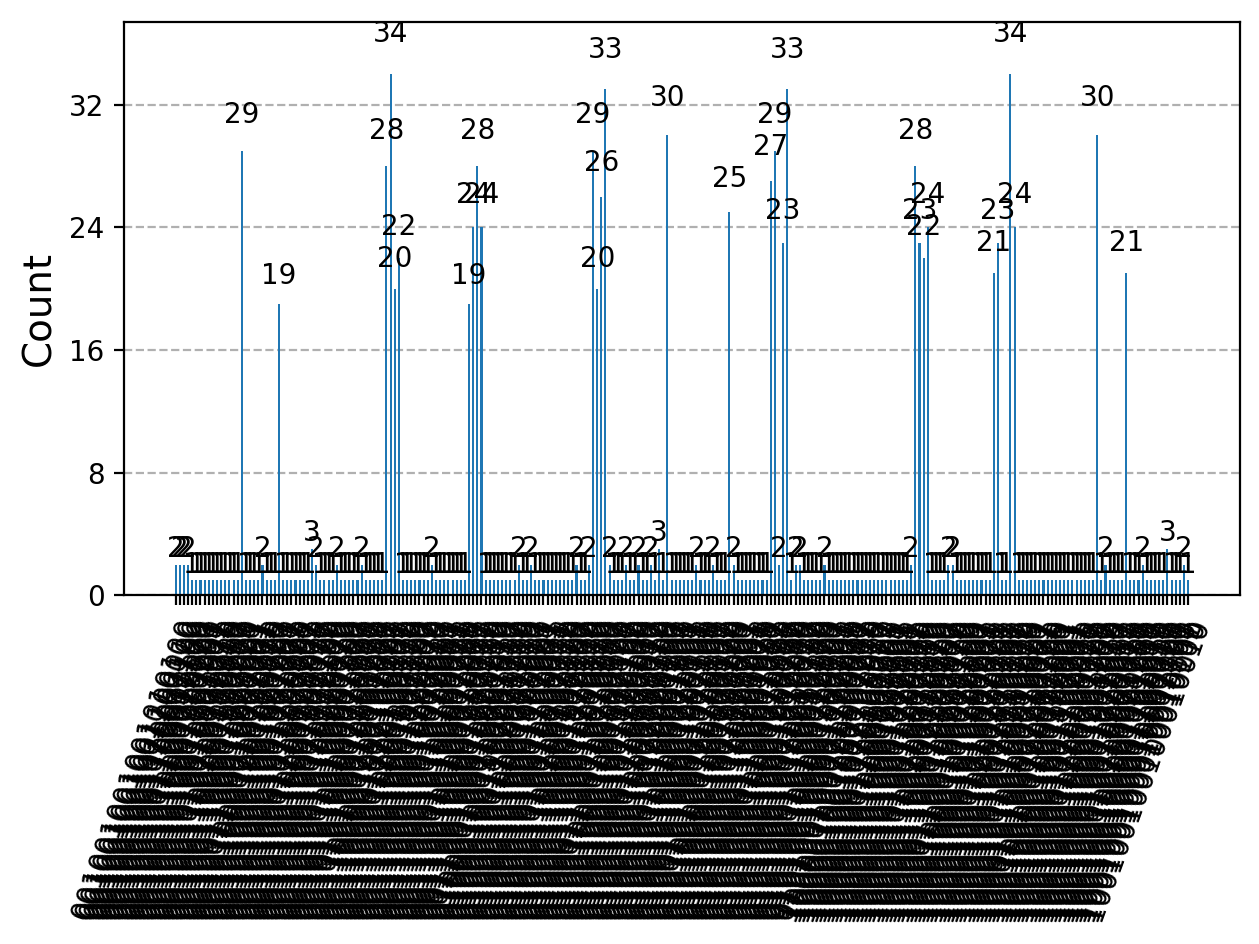

In [47]:
qc = full_circuit(N,K,edges , iterations=iterations)
counts = run_simulation(qc)
plot_histogram(counts) # graph is not readable uncomment on your own risk

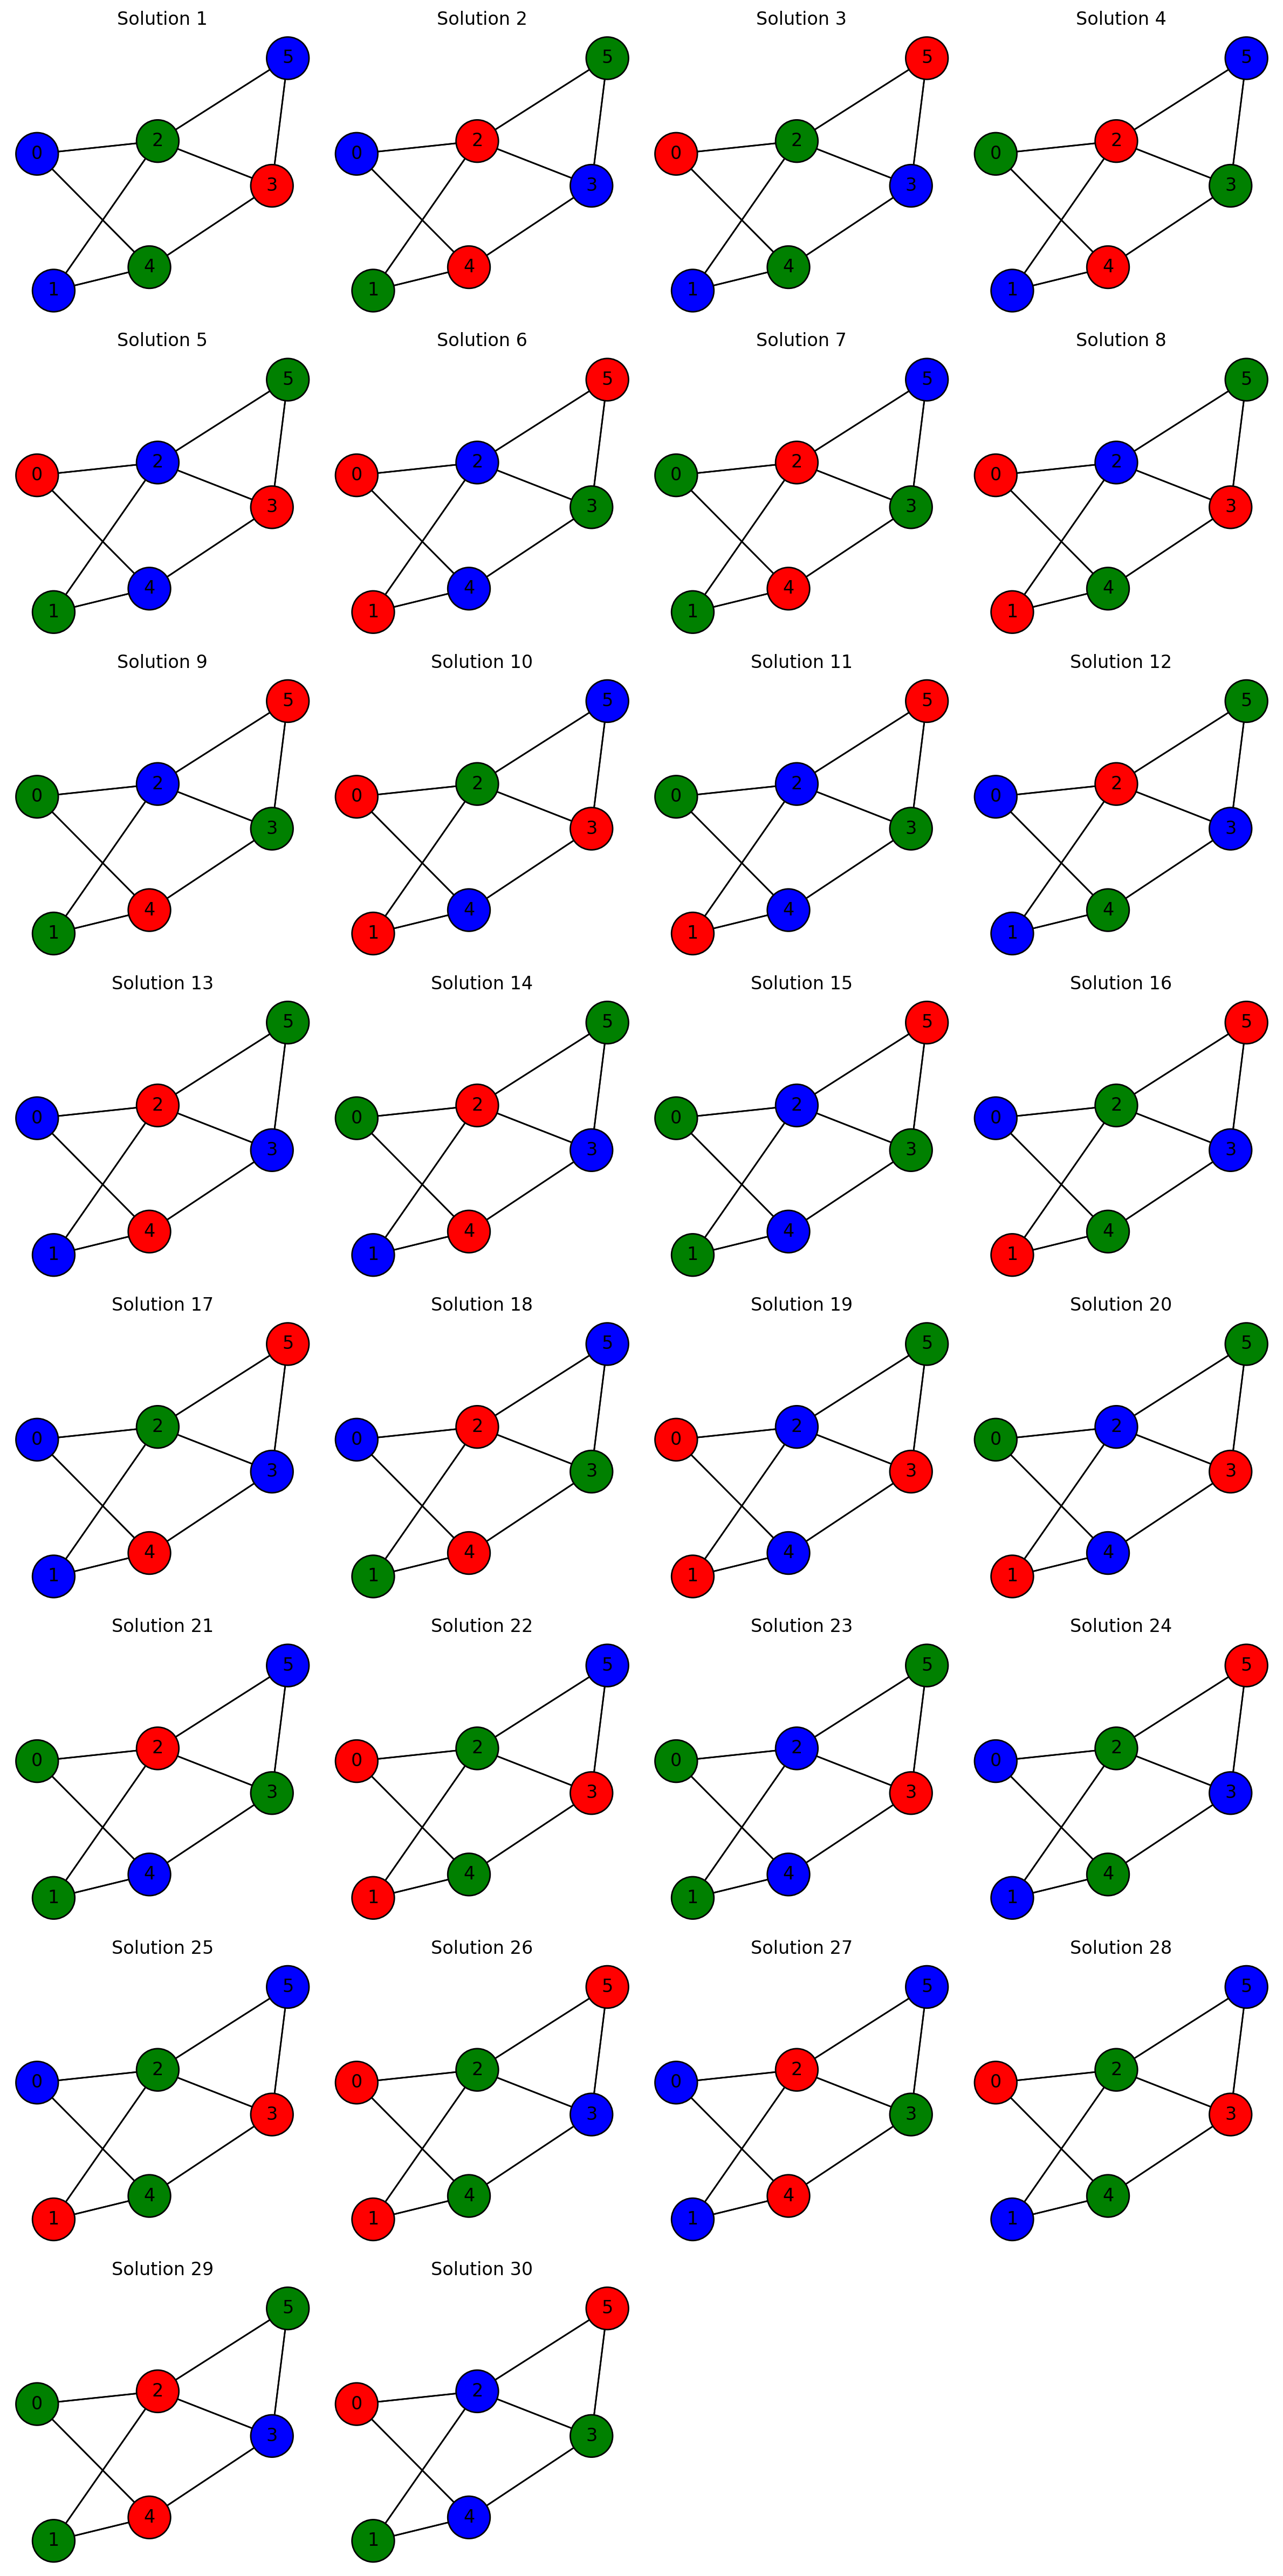

In [48]:
colorings = translator(N,K,counts)
colorings = answer_validity(colorings, edges)
draw_graph(colorings , G, pos)

## References:

- Qiskit, https://qiskit.org/
- Maurice Clerc. A general quantum method to solve the graph K-colouring problem. 2023. ⟨hal-02891847v3⟩
- Alex Fabrikant and Tad Hogg. Graph Coloring with Quantum Heuristics. Edmonton, Alberta,
Canada, 2002
- Lov K. Grover. A fast quantum mechanical algorithm for database search. 1996. ⟨arXiv:quant-ph/9605043⟩